# DeepPCB Raw Data Understanding

Explore the dataset from its files rather than assuming its image size, class balance, or defect counts. Inspect annotation integrity, box geometry, class/split distributions, and possible cross-split leakage. Use validation for model decisions; inspect test only for descriptive auditing and final evaluation.

In [43]:
import hashlib
import os
import platform
from importlib.metadata import PackageNotFoundError, version
from itertools import combinations
from pathlib import Path

import imagehash
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw

RANDOM_SEED = 42
DATA_ROOT = Path(os.environ.get("PCB_DATA_ROOT", Path.cwd() / "Data" / "raw_data")).expanduser()
PREFERRED_SPLIT_ORDER = ("train", "valid", "test")
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}


def display_path(path):
    resolved_path = Path(path).expanduser().resolve()
    try:
        return resolved_path.relative_to(Path.cwd().resolve()).as_posix()
    except ValueError:
        return f"<external>/{resolved_path.name}"


print(f"Python version: {platform.python_version()}")
version_rows = []
for distribution in ("numpy", "pandas", "Pillow", "matplotlib", "ImageHash", "scikit-learn"):
    try:
        package_version = version(distribution)
    except PackageNotFoundError:
        package_version = "not installed"
    version_rows.append({"distribution": distribution, "version": package_version})
display(pd.DataFrame(version_rows).set_index("distribution"))

Python version: 3.13.5


,version
distribution,
numpy,2.1.3
pandas,2.3.2
Pillow,11.1.0
matplotlib,3.10.6
ImageHash,4.3.2
scikit-learn,1.7.2


## Discovery settings

`PCB_DATA_ROOT` có thể chỉ định raw-data root; phần mở rộng ảnh và `RANDOM_SEED` được khai báo ở cell thiết lập. Cell đó cũng ghi Python/package versions để kết quả có thể được tái hiện và đối chiếu môi trường.

In [44]:
def has_deep_pcb_layout(root):
    if not (root / "Class.txt").is_file():
        return False
    return any(
        (split_root / "images").is_dir() and (split_root / "labels").is_dir()
        for split_root in root.iterdir()
        if split_root.is_dir()
    )


candidates = (DATA_ROOT, DATA_ROOT / "DeepPCB")
deep_pcb_base = next(
    (candidate.resolve() for candidate in candidates if has_deep_pcb_layout(candidate)), None
)
if deep_pcb_base is None:
    raise FileNotFoundError(
        f"Expected Class.txt and split-level images/labels folders under {display_path(DATA_ROOT)}"
    )

split_roots = {
    path.name: path
    for path in deep_pcb_base.iterdir()
    if path.is_dir() and (path / "images").is_dir() and (path / "labels").is_dir()
}
if not split_roots:
    raise ValueError(f"No split folders containing images/labels found under {display_path(deep_pcb_base)}")

SPLITS = tuple(sorted(
    split_roots,
    key=lambda name: (
        PREFERRED_SPLIT_ORDER.index(name)
        if name in PREFERRED_SPLIT_ORDER
        else len(PREFERRED_SPLIT_ORDER),
        name,
    ),
))
missing_standard_splits = set(PREFERRED_SPLIT_ORDER).difference(SPLITS)
if missing_standard_splits:
    print(f"Review split layout; standard split names not found: {sorted(missing_standard_splits)}")

split_inventory = []
for split in SPLITS:
    split_root = split_roots[split]
    image_count = sum(
        image.suffix.lower() in IMAGE_SUFFIXES
        for image in (split_root / "images").iterdir()
    )
    label_count = sum(1 for _ in (split_root / "labels").glob("*.txt"))
    split_inventory.append({"split": split, "images": image_count, "labels": label_count})

print(f"Discovered DeepPCB root: {display_path(deep_pcb_base)}")
print("Class.txt contents:", (deep_pcb_base / "Class.txt").read_text(encoding="utf-8").strip())
display(pd.DataFrame(split_inventory).set_index("split"))
sample_label = next((split_roots[SPLITS[0]] / "labels").glob("*.txt"), None)
if sample_label is None:
    raise FileNotFoundError(f"No annotation files found in split {SPLITS[0]!r}")
print("Sample annotation lines:", sample_label.read_text(encoding="utf-8").splitlines()[:5])

Discovered DeepPCB root: Data/raw_data
Class.txt contents: 'open','short','mousebite','spur','copper','pin-hole'


,images,labels
split,,
train,1200,1200
valid,150,150
test,150,150


Sample annotation lines: ['466 441 493 470 3', '454 300 493 396 2', '331 248 364 283 4', '221 314 253 350 4', '151 149 182 175 5']


## 1. Xác nhận cấu trúc dữ liệu

Đã xác định root DeepPCB bằng `Class.txt` và cặp thư mục `images/labels` trong `train`, `valid`, `test`. Bảng inventory và vài dòng annotation mẫu xác nhận dataset được đọc đúng trước khi phân tích nội dung.

In [45]:
CLASS_NAMES = [
    name.strip(" '\"")
    for name in (deep_pcb_base / "Class.txt").read_text(encoding="utf-8").strip().split(",")
    if name.strip(" '\"")
]
if not CLASS_NAMES or len(set(CLASS_NAMES)) != len(CLASS_NAMES):
    raise ValueError(f"Class.txt must define unique, non-empty class names: {CLASS_NAMES}")

label_paths = [
    label_path
    for split in SPLITS
    for label_path in (split_roots[split] / "labels").glob("*.txt")
]
observed_class_ids = set()
for label_path in label_paths:
    for line in label_path.read_text(encoding="utf-8").splitlines():
        values = line.split()
        if len(values) != 5:
            continue
        try:
            observed_class_ids.add(int(values[4]))
        except ValueError:
            continue

if not observed_class_ids:
    raise ValueError("No valid five-field annotations with integer class IDs were found")

CLASS_ID_BASE = min(observed_class_ids)
class_id_range = range(CLASS_ID_BASE, CLASS_ID_BASE + len(CLASS_NAMES))
if max(observed_class_ids) != class_id_range[-1] or not observed_class_ids.issubset(class_id_range):
    raise ValueError(
        f"Observed class IDs {sorted(observed_class_ids)} do not align with "
        f"{len(CLASS_NAMES)} ordered names in Class.txt"
    )
CLASS_ID_TO_INDEX = {class_id: index for index, class_id in enumerate(class_id_range)}

box_cache = {}
annotation_errors = []


def read_boxes(label_path):
    label_path = Path(label_path)
    if label_path in box_cache:
        return box_cache[label_path]

    boxes = []
    if not label_path.is_file():
        box_cache[label_path] = boxes
        return boxes

    for line_number, line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), start=1):
        if not line.strip():
            continue
        values = line.split()
        if len(values) != 5:
            annotation_errors.append({
                "label_path": str(label_path.relative_to(deep_pcb_base)),
                "line": line_number,
                "error": f"Expected 5 values, found {len(values)}",
            })
            continue

        try:
            x1, y1, x2, y2, class_id = map(int, values)
        except ValueError as error:
            annotation_errors.append({
                "label_path": str(label_path.relative_to(deep_pcb_base)),
                "line": line_number,
                "error": f"Non-integer annotation: {error}",
            })
            continue

        if class_id not in CLASS_ID_TO_INDEX:
            message = f"Unknown class ID: {class_id}"
        elif x2 <= x1 or y2 <= y1:
            message = f"Invalid box extent: {values}"
        else:
            class_index = CLASS_ID_TO_INDEX[class_id]
            boxes.append({
                "x1": x1, "y1": y1, "x2": x2, "y2": y2,
                "class_id": class_id,
                "class_index": class_index,
                "class_name": CLASS_NAMES[class_index],
            })
            continue

        annotation_errors.append({
            "label_path": str(label_path.relative_to(deep_pcb_base)),
            "line": line_number,
            "error": message,
        })

    box_cache[label_path] = boxes
    return boxes

## 2. Đọc taxonomy và parser annotation

`Class.txt` là taxonomy theo thứ tự; dải class ID được suy ra từ các label files và đối chiếu với số tên lớp. Parser giả định mỗi dòng là `x1 y1 x2 y2 class_id`, kiểm tra giả định đó trên toàn bộ label và ghi riêng dòng lỗi; `class_index` chỉ là index 0-based nội bộ, không thay ID trong file.

In [31]:
ANNOTATION_COLUMNS = (
    "split", "image_name", "x1", "y1", "x2", "y2",
    "width", "height", "image_width", "image_height",
    "class_id", "class_index", "class_name",
)
image_records = []
box_records = []
missing_label_files = []
unmatched_label_files = []
out_of_bounds_boxes = []

for split in SPLITS:
    images_dir = split_roots[split] / "images"
    labels_dir = split_roots[split] / "labels"
    image_paths = sorted(
        path for path in images_dir.iterdir()
        if path.suffix.lower() in IMAGE_SUFFIXES
    )
    image_stems = {path.stem for path in image_paths}
    unmatched_label_files.extend(
        {"split": split, "label_name": path.name}
        for path in labels_dir.glob("*.txt")
        if path.stem not in image_stems
    )

    for image_path in image_paths:
        label_path = labels_dir / f"{image_path.stem}.txt"
        label_available = label_path.is_file()
        if not label_available:
            missing_label_files.append({"split": split, "image_name": image_path.name})

        with Image.open(image_path) as source:
            width, height = source.size
            source_mode = source.mode
            rgb = np.asarray(source.convert("RGB"))
        is_grayscale = (
            np.array_equal(rgb[..., 0], rgb[..., 1])
            and np.array_equal(rgb[..., 1], rgb[..., 2])
        )
        rgb_float = rgb.astype(np.float32)
        channel_means = rgb_float.mean(axis=(0, 1), dtype=np.float64)
        channel_stds = rgb_float.std(axis=(0, 1), dtype=np.float64)
        luminance = rgb_float.mean(axis=2)
        mean_luminance = float(luminance.mean())
        std_luminance = float(luminance.std())

        boxes = read_boxes(label_path)
        for box in boxes:
            if not (0 <= box["x1"] < box["x2"] <= width and 0 <= box["y1"] < box["y2"] <= height):
                out_of_bounds_boxes.append({
                    "split": split,
                    "image_name": image_path.name,
                    "class_name": box["class_name"],
                    "x1": box["x1"], "y1": box["y1"],
                    "x2": box["x2"], "y2": box["y2"],
                    "image_width": width, "image_height": height,
                })
            box_records.append({
                "split": split,
                "image_name": image_path.name,
                "width": box["x2"] - box["x1"],
                "height": box["y2"] - box["y1"],
                "image_width": width,
                "image_height": height,
                **box,
            })

        image_records.append({
            "split": split,
            "image_name": image_path.name,
            "image_path": image_path,
            "label_path": label_path,
            "label_available": label_available,
            "image_width": width,
            "image_height": height,
            "source_mode": source_mode,
            "is_grayscale": is_grayscale,
            "mean_r": channel_means[0],
            "mean_g": channel_means[1],
            "mean_b": channel_means[2],
            "std_r": channel_stds[0],
            "std_g": channel_stds[1],
            "std_b": channel_stds[2],
            "mean_luminance": mean_luminance,
            "std_luminance": std_luminance,
            "num_boxes": len(boxes),
            "num_classes": len({box["class_index"] for box in boxes}),
        })

manifest = pd.DataFrame(image_records)
annotations = pd.DataFrame(box_records, columns=ANNOTATION_COLUMNS)
if manifest.empty:
    raise ValueError(f"No supported images found under {deep_pcb_base}")

### Detection data schema

Detector input là pixel ảnh; ground truth là từng dòng trong `annotations`, gồm `class_id` và box `(x1, y1, x2, y2)` theo pixel ảnh gốc. `class_name` phục vụ đọc báo cáo, `class_index` là index nội bộ theo `Class.txt`, `width`/`height` là kích thước box; `image_width`/`image_height` dùng để kiểm tra hoặc chuẩn hóa tọa độ. `manifest` chứa metadata mỗi ảnh (`split`, đường dẫn, kích thước, số box/lớp), không phải feature vector đưa vào model.

Cả 1.500 ảnh đều có ít nhất một box và không có ảnh nào không lỗi theo annotation hiện tại. Vì vậy tập này không cung cấp ảnh board sạch để đánh giá false positive; ảnh không có label file cũng không thể mặc nhiên xem là nền.

Class order: [(0, 'open'), (1, 'short'), (2, 'mousebite'), (3, 'spur'), (4, 'copper'), (5, 'pin-hole')]
Images: 1,500 | valid boxes: 10,013
Original image modes:


,images
source_mode,
L,1462
RGB,38


Pixel-grayscale images: 1,499/1,500
Images with non-grayscale pixel channels:


,split,image_name,source_mode
29,train,01_PCB__1030.jpg,RGB


Pooled RGB pixel moments by split (0-1 values are RGB/255 normalization candidates):


pixel_mean_0_255  pixel_std_0_255  mean_0_1  std_0_1
split channel                                                      
train R                166.1598         121.0085    0.6516   0.4745
      G                166.1618         121.0080    0.6516   0.4745
      B                166.1598         121.0085    0.6516   0.4745
valid R                162.5374         121.9919    0.6374   0.4784
      G                162.5374         121.9919    0.6374   0.4784
      B                162.5374         121.9919    0.6374   0.4784
test  R                166.1520         121.0267    0.6516   0.4746
      G                166.1520         121.0267    0.6516   0.4746
      B                166.1520         121.0267    0.6516   0.4746

Per-image brightness and contrast distribution by split:


mean_luminance                               std_luminance         \
                mean    std  median    min     max          mean    std   
split                                                                     
test          166.15  53.39  172.13  36.68  254.75        106.05  23.95   
train         166.16  49.86  173.10  43.33  254.92        108.32  20.67   
valid         162.54  51.52  172.86  46.18  250.86        109.08  18.71   

                              
       median    min     max  
split                         
test   114.67   7.91  127.27  
train  115.63   4.55  127.40  
valid  114.30  32.06  127.27

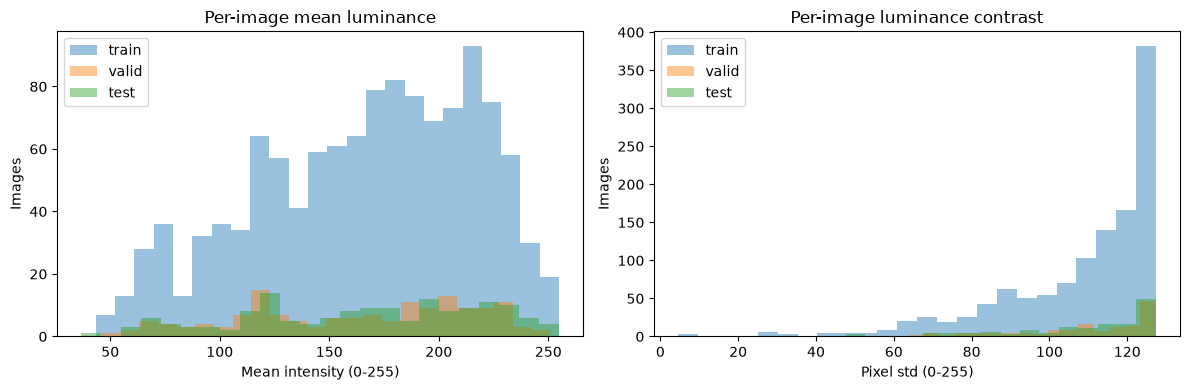

,count
annotation parse errors,0
out-of-bounds boxes,0
images without label files,0
labels without images,0


,images
split,
test,150
train,1200
valid,150


,min,p05,p10,p25,median,p75,p90,max
Width (pixels),18.000,27.000,28.000,31.000,35.000,42.000,53.000,173.000
Height (pixels),19.000,25.000,26.000,29.000,33.000,39.000,48.000,152.000
Width (% image),2.812,4.219,4.375,4.844,5.469,6.562,8.281,27.031
Height (% image),2.969,3.906,4.062,4.531,5.156,6.094,7.500,23.750


In [46]:
print("Class order:", list(enumerate(CLASS_NAMES)))
print(f"Images: {len(manifest):,} | valid boxes: {len(annotations):,}")
print("Original image modes:")
display(manifest["source_mode"].value_counts().rename("images").to_frame())
non_grayscale_images = manifest.loc[
    ~manifest["is_grayscale"], ["split", "image_name", "source_mode"]
]
print(f"Pixel-grayscale images: {manifest['is_grayscale'].sum():,}/{len(manifest):,}")
print("Images with non-grayscale pixel channels:")
display(non_grayscale_images)

pixel_columns = [
    "mean_r", "mean_g", "mean_b", "std_r", "std_g", "std_b",
    "mean_luminance", "std_luminance",
]
if not np.isfinite(manifest[pixel_columns].to_numpy(dtype=float)).all():
    raise ValueError("Per-image pixel statistics contain non-finite values")
pixel_summary_rows = []
for split, split_manifest in manifest.groupby("split", sort=False):
    for channel in ("r", "g", "b"):
        image_means = split_manifest[f"mean_{channel}"].to_numpy(dtype=float)
        image_stds = split_manifest[f"std_{channel}"].to_numpy(dtype=float)
        pooled_mean = image_means.mean()
        pooled_std = np.sqrt(np.mean(image_stds ** 2 + image_means ** 2) - pooled_mean ** 2)
        pixel_summary_rows.append({
            "split": split,
            "channel": channel.upper(),
            "pixel_mean_0_255": pooled_mean,
            "pixel_std_0_255": pooled_std,
            "mean_0_1": pooled_mean / 255,
            "std_0_1": pooled_std / 255,
        })
print("Pooled RGB pixel moments by split (0-1 values are RGB/255 normalization candidates):")
display(pd.DataFrame(pixel_summary_rows).set_index(["split", "channel"]).round(4))
print("Per-image brightness and contrast distribution by split:")
display(manifest.groupby("split")[
    ["mean_luminance", "std_luminance"]
].agg(["mean", "std", "median", "min", "max"]).round(2))

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
for split in SPLITS:
    split_manifest = manifest.loc[manifest["split"] == split]
    axes[0].hist(split_manifest["mean_luminance"], bins=24, alpha=0.45, label=split)
    axes[1].hist(split_manifest["std_luminance"], bins=24, alpha=0.45, label=split)
axes[0].set(title="Per-image mean luminance", xlabel="Mean intensity (0-255)", ylabel="Images")
axes[1].set(title="Per-image luminance contrast", xlabel="Pixel std (0-255)", ylabel="Images")
for axis in axes:
    axis.legend()
figure.tight_layout()
plt.show()

audit_counts = pd.Series({
    "annotation parse errors": len(annotation_errors),
    "out-of-bounds boxes": len(out_of_bounds_boxes),
    "images without label files": len(missing_label_files),
    "labels without images": len(unmatched_label_files),
}, name="count")
display(audit_counts.to_frame())

diagnostics = (
    ("Annotation errors", annotation_errors),
    ("Out-of-bounds boxes", out_of_bounds_boxes),
    ("Images missing labels", missing_label_files),
    ("Labels without images", unmatched_label_files),
)
for title, records in diagnostics:
    if records:
        print(title)
        display(pd.DataFrame(records))

display(manifest.groupby("split").size().rename("images").to_frame())
if annotations.empty:
    print("No valid boxes found; box-size analysis skipped.")
else:
    box_sizes = pd.DataFrame({
        "Width (pixels)": annotations["width"],
        "Height (pixels)": annotations["height"],
        "Width (% image)": 100 * annotations["width"] / annotations["image_width"],
        "Height (% image)": 100 * annotations["height"] / annotations["image_height"],
    })
    quantile_levels = [0.0, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 1.0]
    quantile_names = {
        0.0: "min", 0.05: "p05", 0.10: "p10", 0.25: "p25",
        0.50: "median", 0.75: "p75", 0.90: "p90", 1.0: "max",
    }
    box_quantiles = box_sizes.quantile(quantile_levels).T.rename(columns=quantile_names)
    display(box_quantiles.round(3))

## 3. Kiểm tra chất lượng, pixel và kích thước box

Bảng tổng hợp lỗi parse, lệch cặp ảnh/nhãn, box ngoài ảnh và mode gốc của ảnh. Pixel mean/std RGB được tính trên thang 0–255 và báo thêm candidate sau khi chia 255; histogram cho phân bố mean luminance/contrast theo ảnh trong từng split. Thống kê này hỗ trợ chọn normalization nhưng không thay thế việc so sánh preprocessing của pretrained backbone. Box nhỏ cần được bảo toàn khi chọn input size cho detector.

Annotated full-image samples: train


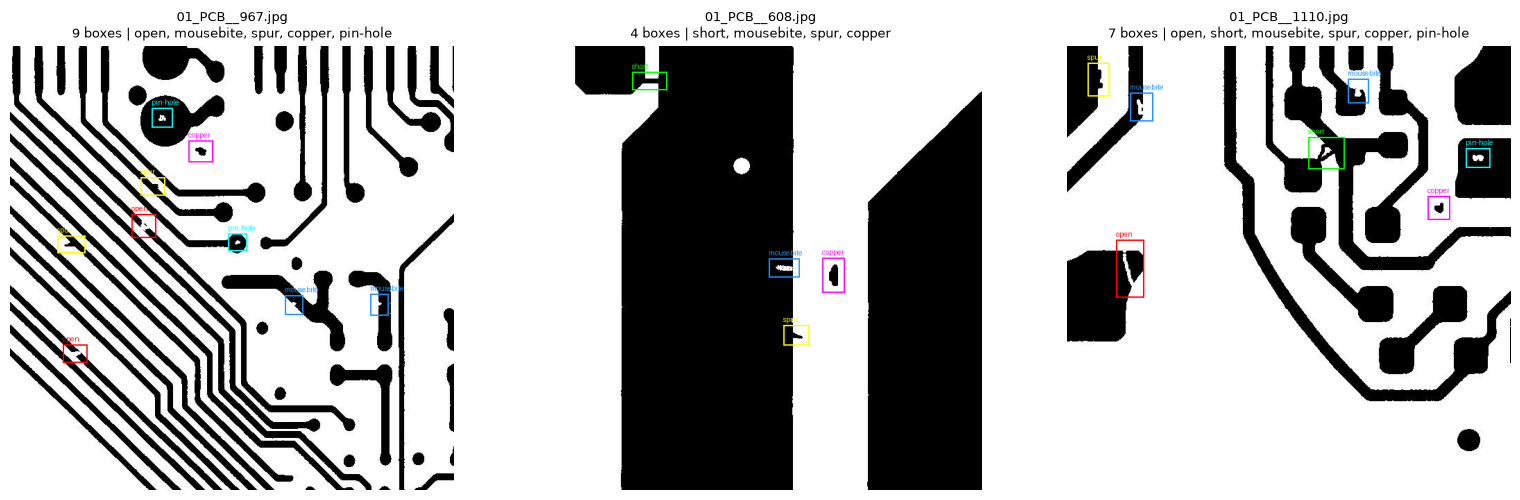

Annotated full-image samples: valid


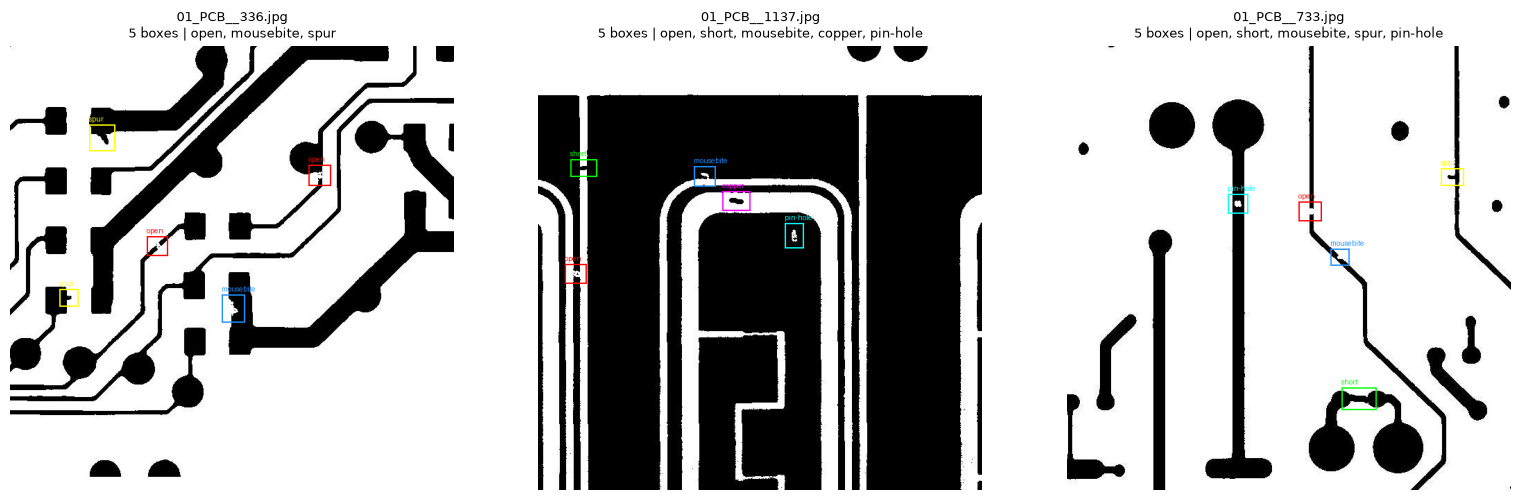

Annotated full-image samples: test


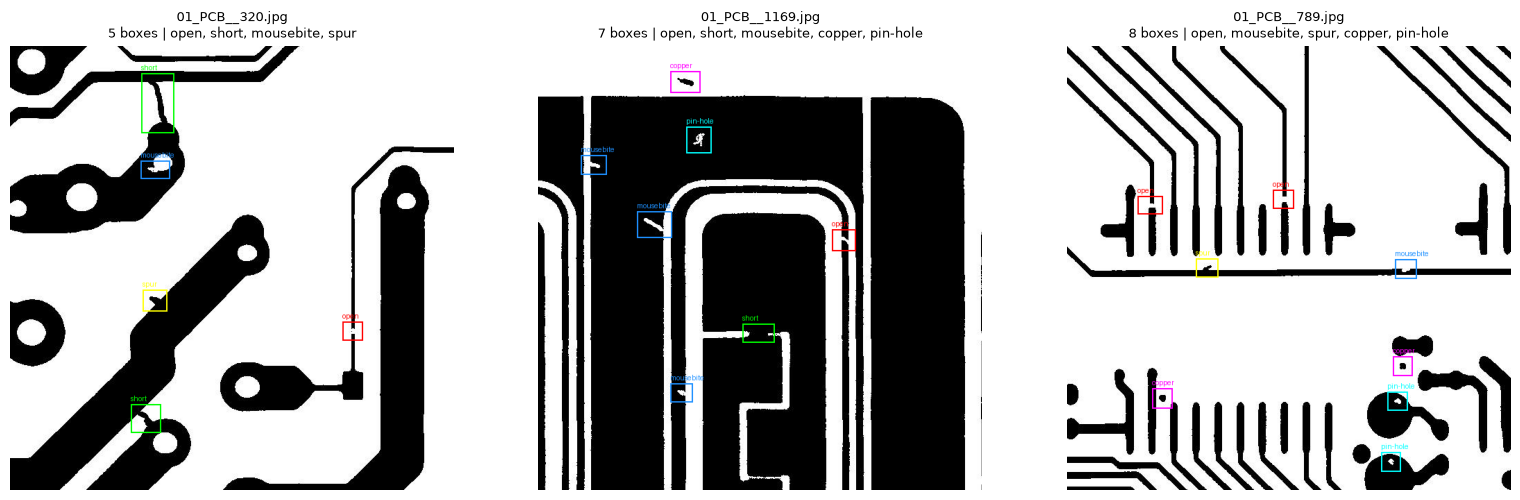

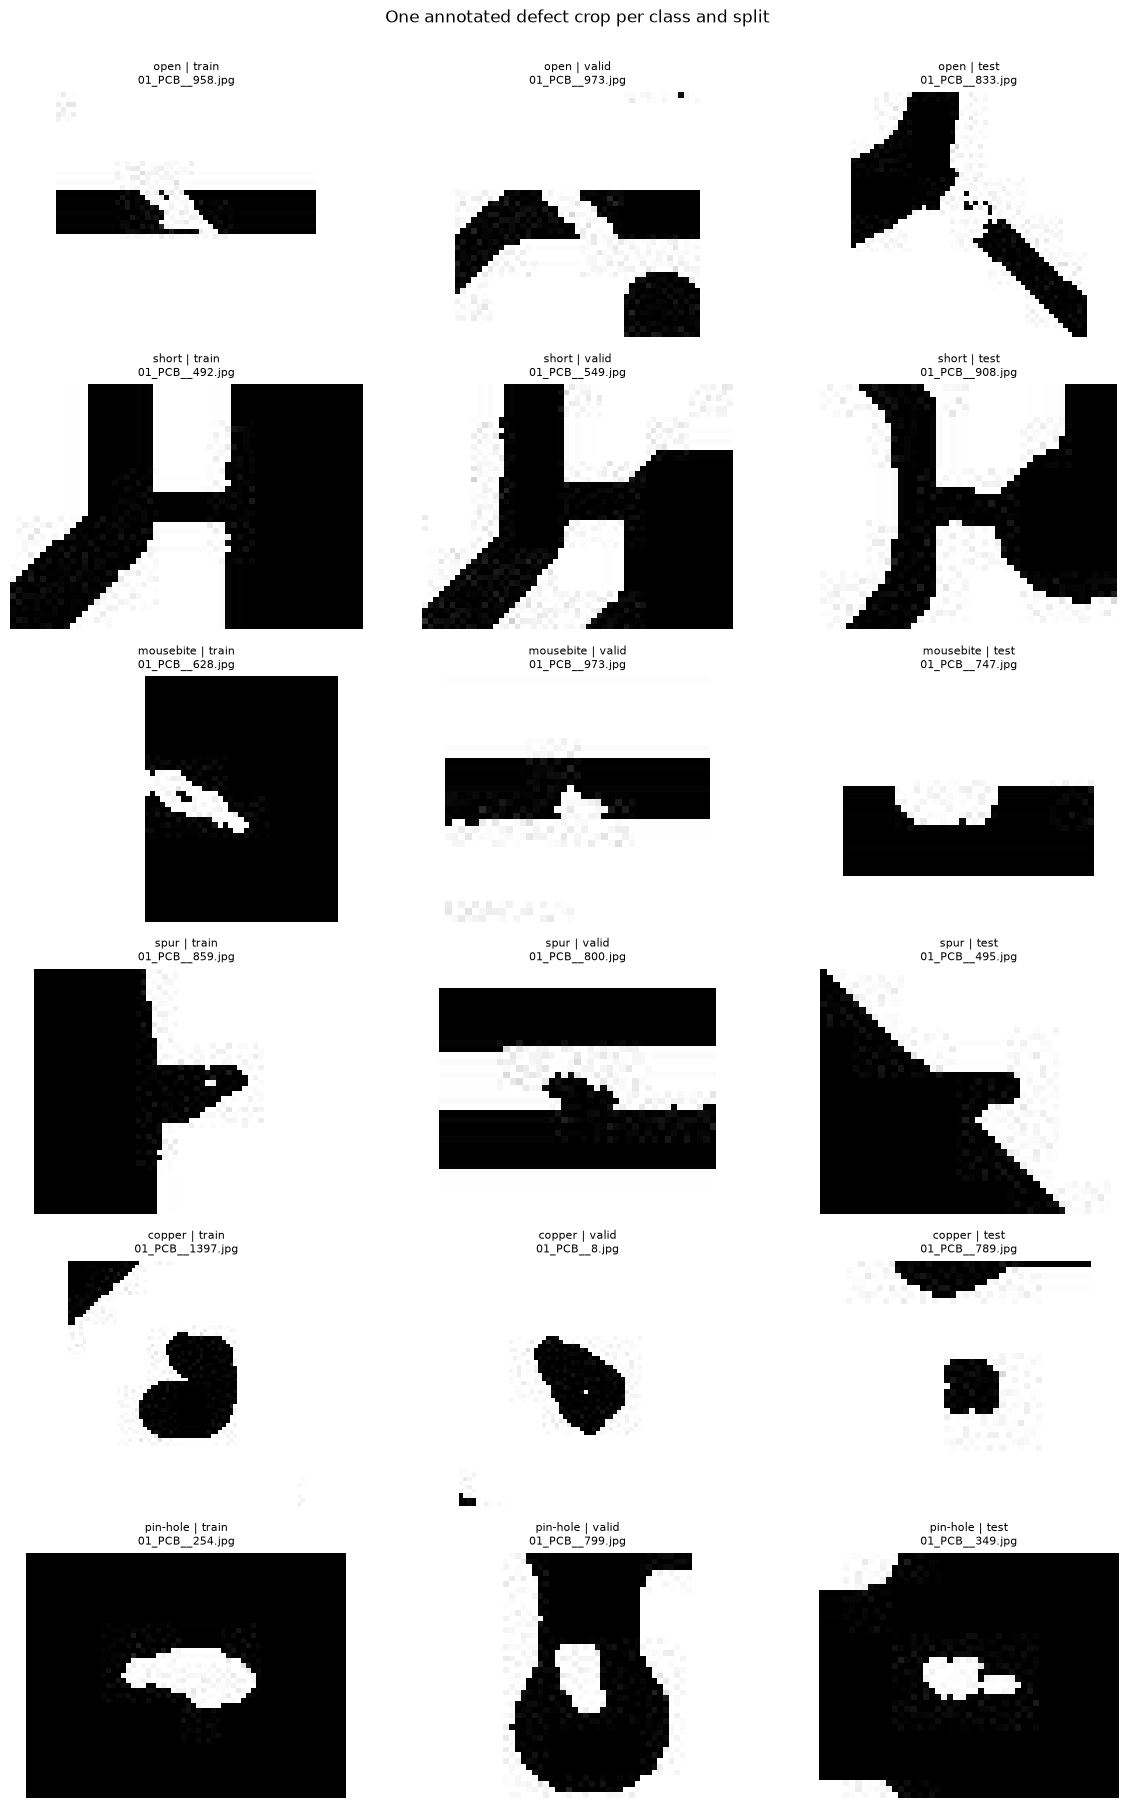

In [50]:
def show_annotated_samples(split="train", num_samples=4, random_state=RANDOM_SEED):
    if num_samples < 1:
        raise ValueError("num_samples must be positive")

    split_manifest = manifest.loc[manifest["split"] == split]
    if split_manifest.empty:
        raise ValueError(f"No images found for split: {split}")
    samples = split_manifest.sample(
        n=min(num_samples, len(split_manifest)),
        random_state=random_state,
    )

    colors = ["red", "lime", "dodgerblue", "yellow", "magenta", "cyan"]
    figure, axes = plt.subplots(1, len(samples), figsize=(16, 5))
    for axis, row in zip(np.atleast_1d(axes), samples.itertuples()):
        with Image.open(row.image_path) as source:
            image = source.convert("RGB")
        draw = ImageDraw.Draw(image)
        boxes = read_boxes(row.label_path)
        for box in boxes:
            color = colors[box["class_index"]]
            draw.rectangle(
                (box["x1"], box["y1"], box["x2"], box["y2"]),
                outline=color,
                width=2,
            )
            draw.text((box["x1"], max(0, box["y1"] - 14)), box["class_name"], fill=color)

        class_names = sorted(
            {box["class_name"] for box in boxes}, key=CLASS_NAMES.index
        )
        axis.imshow(image)
        axis.set_title(
            f"{row.image_name}\n{len(boxes)} boxes | {', '.join(class_names)}",
            fontsize=9,
        )
        axis.axis("off")

    figure.tight_layout()
    plt.show()


for split in SPLITS:
    print(f"Annotated full-image samples: {split}")
    show_annotated_samples(split=split, num_samples=3)

figure, axes = plt.subplots(len(CLASS_NAMES), len(SPLITS), figsize=(12, 18))
for row_index, class_name in enumerate(CLASS_NAMES):
    for column_index, split in enumerate(SPLITS):
        candidates = annotations.loc[
            (annotations["class_name"] == class_name)
            & (annotations["split"] == split)
        ].sort_values("image_name")
        if candidates.empty:
            axes[row_index, column_index].set_title(f"{class_name} | {split}: no boxes")
            axes[row_index, column_index].axis("off")
            continue
        sample = candidates.sample(n=1, random_state=RANDOM_SEED).iloc[0]
        image_row = manifest.loc[
            (manifest["split"] == split)
            & (manifest["image_name"] == sample["image_name"])
        ].iloc[0]
        padding = max(6, int(0.2 * max(sample["width"], sample["height"])))
        left = max(0, int(sample["x1"] - padding))
        top = max(0, int(sample["y1"] - padding))
        right = min(int(sample["image_width"]), int(sample["x2"] + padding))
        bottom = min(int(sample["image_height"]), int(sample["y2"] + padding))
        with Image.open(image_row["image_path"]) as source:
            crop = source.convert("RGB").crop((left, top, right, bottom))
        axes[row_index, column_index].imshow(crop)
        axes[row_index, column_index].set_title(
            f"{class_name} | {split}\n{sample['image_name']}", fontsize=8
        )
        axes[row_index, column_index].axis("off")
figure.suptitle("One annotated defect crop per class and split", y=1.002)
figure.tight_layout()
plt.show()

## 4. Kiểm tra trực quan box

Overlay có mẫu ngẫu nhiên từ cả `train`, `valid`, `test` (3 ảnh/split); gallery crop hiển thị một box mỗi lớp ở mỗi split. Đây là spot-check, không thay thế rà soát thủ công toàn bộ 10.013 box. Cần đặc biệt kiểm tra các crop nhỏ/ít tương phản và cặp dHash được liệt kê ở phần sau. Các crop chỉ phục vụ review; detector vẫn nhận ảnh toàn board cùng bounding box.

Image/box counts and image-level prevalence by class:


,images,boxes,prevalence
class_name,,,
open,1344,1942,0.896000
short,1101,1506,0.734000
mousebite,1269,1965,0.846000
spur,1184,1625,0.789333
copper,1241,1474,0.827333
pin-hole,1315,1501,0.876667


Image dimensions:


,,count
image_width,image_height,
640,640,1500


Boxes per image: {'count': 1500.0, 'mean': 6.68, 'std': 1.81, 'min': 1.0, '25%': 5.0, '50%': 7.0, '75%': 8.0, 'max': 15.0}
Classes per image: {1: 5, 2: 16, 3: 72, 4: 322, 5: 597, 6: 488}
Images with zero boxes: 0/1500
Pairwise co-occurrence lift (observed / expected under independent labels):


,open,short,mousebite,spur,copper,pin-hole
open,NaN,1.05,0.99,1.01,1.00,1.00
short,1.05,NaN,0.97,1.01,0.99,0.99
mousebite,0.99,0.97,NaN,0.99,1.01,1.00
spur,1.01,1.01,0.99,NaN,0.98,1.01
copper,1.00,0.99,1.01,0.98,NaN,1.03
pin-hole,1.00,0.99,1.00,1.01,1.03,NaN


Box size (pixels):


,width,height
count,10013.0,10013.0
mean,38.9,35.7
std,13.4,11.2
min,18.0,19.0
25%,31.0,29.0
50%,35.0,33.0
75%,42.0,39.0
90%,53.0,48.0
max,173.0,152.0


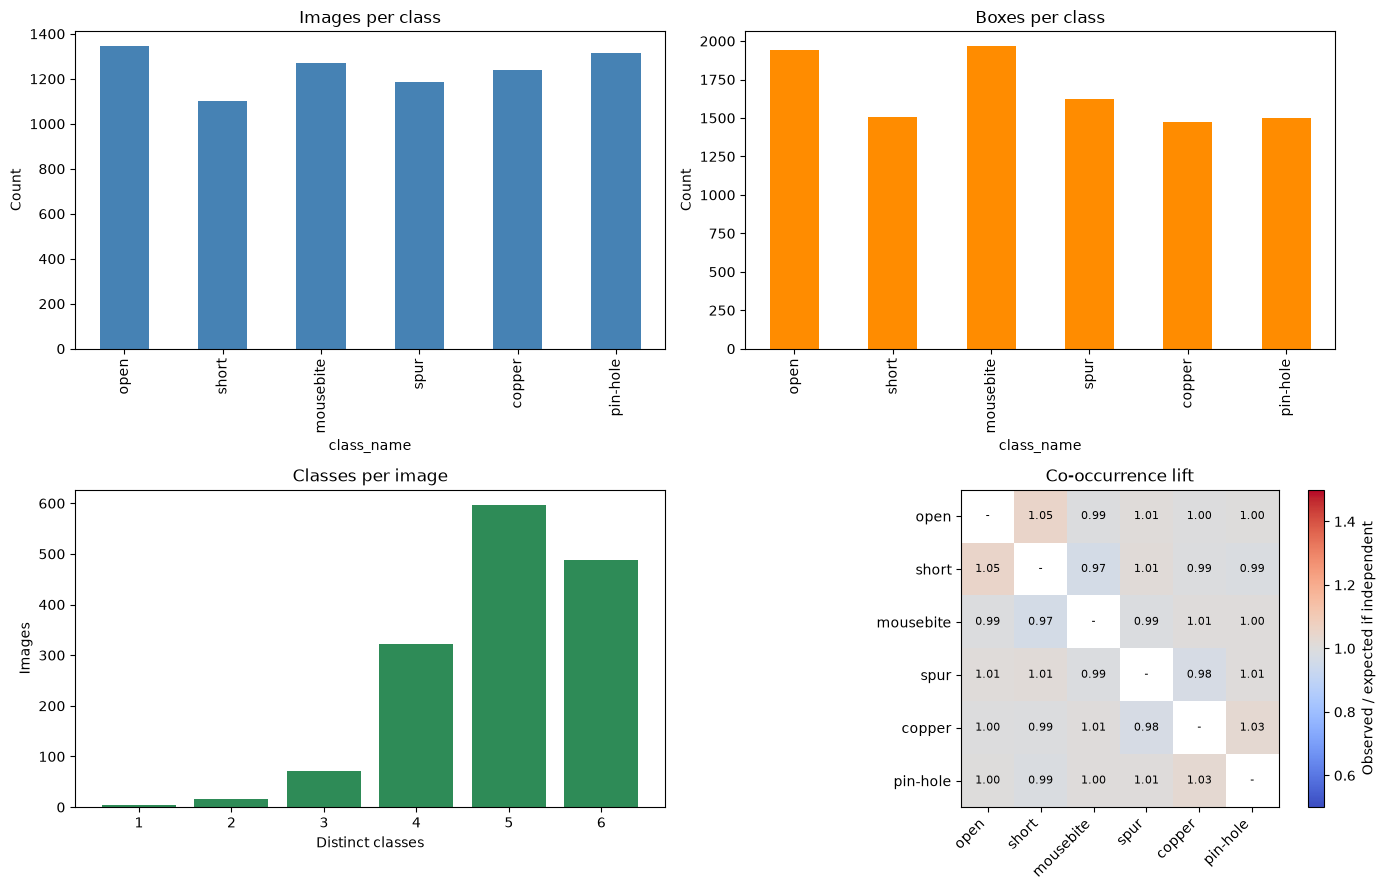

In [42]:
image_index = pd.MultiIndex.from_frame(manifest[["split", "image_name"]])
image_class_presence = annotations.groupby(
    ["split", "image_name", "class_name"]
).size().unstack("class_name", fill_value=0)
target_frame = image_class_presence.reindex(
    index=image_index, columns=CLASS_NAMES, fill_value=0
).gt(0).astype(np.uint8).reset_index(drop=True)
image_class_counts = target_frame.sum().astype(int)
box_class_counts = annotations["class_name"].value_counts().reindex(CLASS_NAMES, fill_value=0)
presence_array = target_frame.to_numpy(dtype=np.int64)
cooccurrence = pd.DataFrame(
    presence_array.T @ presence_array,
    index=CLASS_NAMES,
    columns=CLASS_NAMES,
)
expected_cooccurrence = np.outer(image_class_counts, image_class_counts) / len(manifest)
cooccurrence_lift = cooccurrence.to_numpy() / expected_cooccurrence
np.fill_diagonal(cooccurrence_lift, np.nan)
cooccurrence_lift = pd.DataFrame(
    cooccurrence_lift, index=CLASS_NAMES, columns=CLASS_NAMES
)

print("Image/box counts and image-level prevalence by class:")
display(pd.DataFrame({
    "images": image_class_counts,
    "boxes": box_class_counts,
    "prevalence": image_class_counts / len(manifest),
}))
print("Image dimensions:")
display(manifest.groupby(["image_width", "image_height"]).size().rename("count").to_frame())
print("Boxes per image:", manifest["num_boxes"].describe().round(2).to_dict())
classes_per_image = target_frame.sum(axis=1)
classes_per_image_distribution = classes_per_image.value_counts().sort_index()
print("Classes per image:", classes_per_image_distribution.to_dict())
print(f"Images with zero boxes: {(manifest['num_boxes'] == 0).sum()}/{len(manifest)}")
print("Pairwise co-occurrence lift (observed / expected under independent labels):")
display(cooccurrence_lift.round(2))
print("Box size (pixels):")
display(annotations[["width", "height"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(1))

figure, axes = plt.subplots(2, 2, figsize=(14, 9))
for axis, values, title, color in zip(
    axes.flat[:2], (image_class_counts, box_class_counts),
    ("Images per class", "Boxes per class"), ("steelblue", "darkorange")
):
    values.plot.bar(ax=axis, title=title, color=color)
    axis.set_ylabel("Count")

hist = classes_per_image_distribution
axes[1, 0].bar(hist.index, hist.values, color="seagreen")
axes[1, 0].set(title="Classes per image", xlabel="Distinct classes", ylabel="Images")

heatmap = axes[1, 1].imshow(
    cooccurrence_lift.to_numpy(), cmap="coolwarm", vmin=0.5, vmax=1.5
)
axes[1, 1].set(xticks=range(len(CLASS_NAMES)), xticklabels=CLASS_NAMES,
                yticks=range(len(CLASS_NAMES)), yticklabels=CLASS_NAMES,
                title="Co-occurrence lift")
plt.setp(axes[1, 1].get_xticklabels(), rotation=45, ha="right")
for row, column in np.ndindex(cooccurrence_lift.shape):
    value = cooccurrence_lift.iat[row, column]
    label = "-" if np.isnan(value) else f"{value:.2f}"
    axes[1, 1].text(column, row, label, ha="center", va="center", fontsize=8)
figure.colorbar(heatmap, ax=axes[1, 1], fraction=0.046,
                label="Observed / expected if independent")
figure.tight_layout()
plt.show()

## 5. Phân bố lớp và đồng xuất hiện

Phân bố số lớp/ảnh là `{1: 5, 2: 16, 3: 72, 4: 322, 5: 597, 6: 488}`; 72,3% ảnh có ít nhất 5/6 lớp. Prevalence lớp nằm trong 0,734–0,896; đây là thống kê coverage nhãn ở cấp ảnh để hiểu dữ liệu và split, không phải định nghĩa hay metric của bài toán.

Raw co-occurrence counts bị chi phối bởi prevalence cao. Heatmap dùng lift `observed / expected under independence`; các cặp nằm khoảng 0,97–1,05, nên đồng xuất hiện hầu như không cho thêm tín hiệu cặp lớp. Mẫu phân bố này phù hợp với khả năng defect được chèn/thiết kế có kiểm soát, nhưng thống kê hiện có không chứng minh nguồn gốc nhân tạo; cần xác minh provenance trước khi khái quát sang ảnh sản xuất thực tế. Cell kế tiếp phân tích riêng kích thước/aspect ratio theo lớp, tâm box, overlap và anchor.

Box geometry by class (aspect ratio = width / height; small = area < 32^2 pixels):


,boxes,median_width,median_height,median_area,median_aspect_ratio,aspect_ratio_p10,aspect_ratio_p90,small_boxes,small_fraction
class_name,,,,,,,,,
open,1942,38.0,34.0,1320.0,1.135,0.744,1.852,417,0.215
short,1506,41.0,36.0,1486.5,1.188,0.520,2.159,149,0.099
mousebite,1965,34.0,30.0,1024.0,1.139,0.857,1.464,976,0.497
spur,1625,34.0,32.0,1080.0,1.071,0.813,1.352,684,0.421
copper,1474,36.0,36.0,1292.0,1.000,0.788,1.297,325,0.220
pin-hole,1501,33.0,32.0,1085.0,1.029,0.778,1.346,653,0.435


Overall boxes with area < 1,024 px^2: 3,204/10,013 (32.0%)


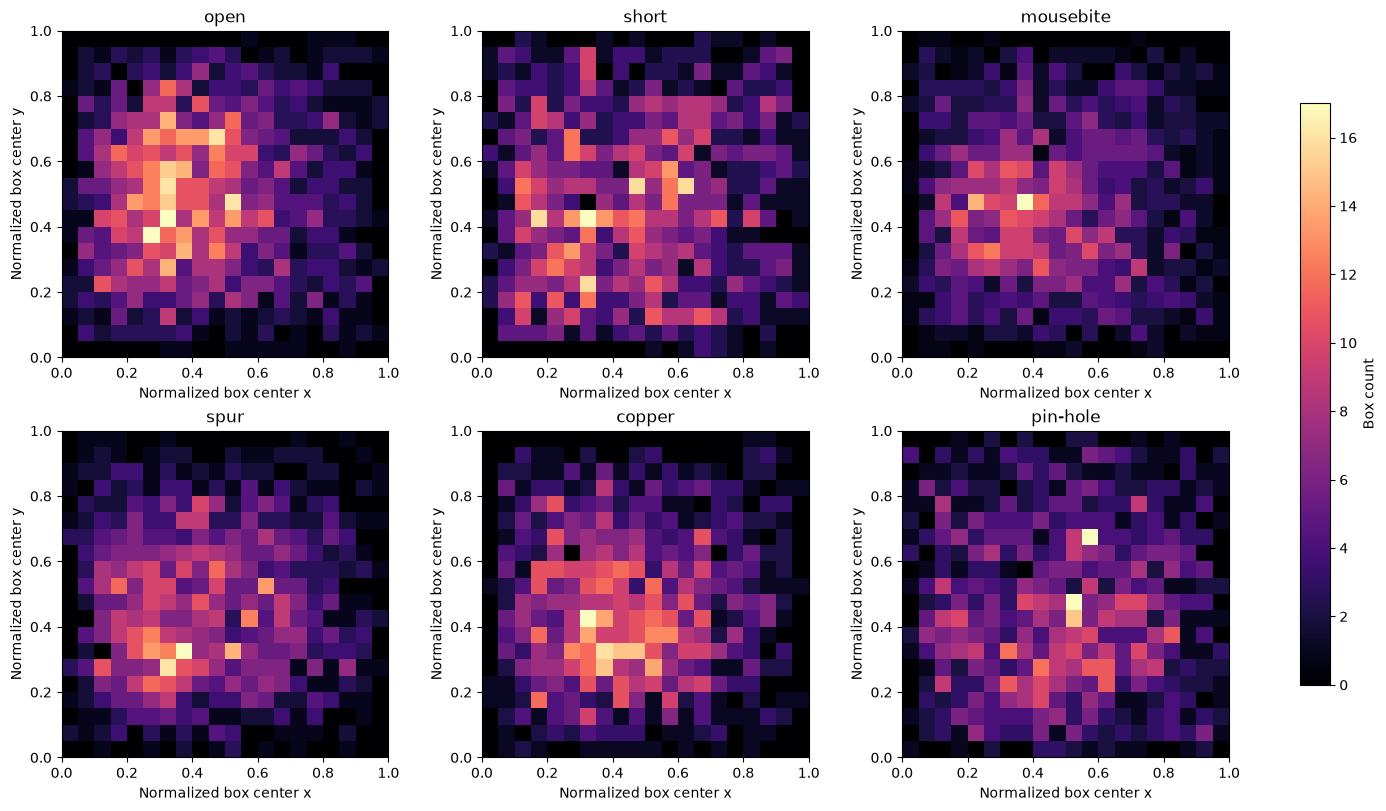

Box overlap audit within each image (IoU is geometric overlap, not proof of duplicate annotation):
Box pairs compared: 30,868
Pairs with IoU >= 0.5: 0 | exact-coordinate pairs: 0
scikit-learn KMeans unavailable (DLL load failed while importing _propack: The specified module could not be found.); using NumPy Lloyd K-means fallback.
Nine Euclidean K-means anchors fitted on train boxes only (descriptive initialization):


,anchor_width_px,anchor_height_px,train_boxes_assigned
0,30.9,28.8,2635
1,39.9,31.0,1742
2,33.6,39.3,1743
3,54.2,32.1,601
4,33.2,57.9,388
5,49.8,49.6,509
6,79.0,41.6,245
7,115.6,45.2,71
8,55.4,95.8,90


Median and p05 box footprint after square resize, with feature-grid cells at selected strides:


,box_quantile,input_size,width_px,height_px,cells_at_stride_8,cells_at_stride_16,cells_at_stride_32
0,p05,640,27.00,25.00,3.38 x 3.12,1.69 x 1.56,0.84 x 0.78
1,p05,416,17.55,16.25,2.19 x 2.03,1.10 x 1.02,0.55 x 0.51
2,p05,320,13.50,12.50,1.69 x 1.56,0.84 x 0.78,0.42 x 0.39
3,median,640,35.00,33.00,4.38 x 4.12,2.19 x 2.06,1.09 x 1.03
4,median,416,22.75,21.45,2.84 x 2.68,1.42 x 1.34,0.71 x 0.67
5,median,320,17.50,16.50,2.19 x 2.06,1.09 x 1.03,0.55 x 0.52


Stride describes feature-map sampling; exact receptive field depends on the chosen CNN architecture.
Template/reference paths found under Data/raw_data: 0
No template/reference assets are present in the configured data root; this notebook does not use template images.
Split/provenance metadata files found: 0
No split manifest/provenance file found; folder counts alone cannot establish whether this is an official or user-created split.


In [51]:
geometry = annotations.assign(
    area=annotations["width"] * annotations["height"],
    aspect_ratio=annotations["width"] / annotations["height"],
    center_x=(annotations["x1"] + annotations["x2"]) / (2 * annotations["image_width"]),
    center_y=(annotations["y1"] + annotations["y2"]) / (2 * annotations["image_height"]),
)
SMALL_BOX_AREA = 32 ** 2
geometry["is_small"] = geometry["area"] < SMALL_BOX_AREA

print("Box geometry by class (aspect ratio = width / height; small = area < 32^2 pixels):")
box_geometry_summary = geometry.groupby("class_name").agg(
    boxes=("area", "size"),
    median_width=("width", "median"),
    median_height=("height", "median"),
    median_area=("area", "median"),
    median_aspect_ratio=("aspect_ratio", "median"),
    aspect_ratio_p10=("aspect_ratio", lambda values: values.quantile(0.10)),
    aspect_ratio_p90=("aspect_ratio", lambda values: values.quantile(0.90)),
    small_boxes=("is_small", "sum"),
    small_fraction=("is_small", "mean"),
).reindex(CLASS_NAMES)
display(box_geometry_summary.round(3))
print(
    f"Overall boxes with area < {SMALL_BOX_AREA:,} px^2: "
    f"{geometry['is_small'].sum():,}/{len(geometry):,} "
    f"({geometry['is_small'].mean():.1%})"
)

figure, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
for axis, class_name in zip(axes.flat, CLASS_NAMES):
    class_boxes = geometry.loc[geometry["class_name"] == class_name]
    center_counts, _, _ = np.histogram2d(
        class_boxes["center_x"], class_boxes["center_y"],
        bins=20, range=((0, 1), (0, 1)),
    )
    image = axis.imshow(center_counts.T, origin="lower", extent=(0, 1, 0, 1), cmap="magma")
    axis.set(title=class_name, xlabel="Normalized box center x", ylabel="Normalized box center y")
figure.colorbar(image, ax=axes, label="Box count", shrink=0.8)
plt.show()

print("Box overlap audit within each image (IoU is geometric overlap, not proof of duplicate annotation):")
overlap_pairs = []
exact_box_pairs = []
image_pair_count = 0
for (split_name, image_name), image_boxes in geometry.groupby(["split", "image_name"]):
    box_rows = list(image_boxes.itertuples(index=False))
    for left_box_index, right_box_index in combinations(range(len(box_rows)), 2):
        left_box = box_rows[left_box_index]
        right_box = box_rows[right_box_index]
        intersection_width = max(0, min(left_box.x2, right_box.x2) - max(left_box.x1, right_box.x1))
        intersection_height = max(0, min(left_box.y2, right_box.y2) - max(left_box.y1, right_box.y1))
        intersection = intersection_width * intersection_height
        union = left_box.area + right_box.area - intersection
        iou = intersection / union if union else 0.0
        is_exact = (
            left_box.x1 == right_box.x1 and left_box.y1 == right_box.y1
            and left_box.x2 == right_box.x2 and left_box.y2 == right_box.y2
        )
        exact_box_pairs.append(is_exact)
        image_pair_count += 1
        if iou >= 0.5:
            overlap_pairs.append({
                "split": split_name,
                "image_name": image_name,
                "left_class": left_box.class_name,
                "right_class": right_box.class_name,
                "iou": iou,
                "exact_same_box": is_exact,
            })
print(f"Box pairs compared: {image_pair_count:,}")
print(f"Pairs with IoU >= 0.5: {len(overlap_pairs):,} | exact-coordinate pairs: {sum(exact_box_pairs):,}")
if overlap_pairs:
    display(pd.DataFrame(overlap_pairs).sort_values("iou", ascending=False).head(25).round(3))

train_box_sizes = geometry.loc[geometry["split"] == "train", ["width", "height"]].to_numpy(dtype=float)
ANCHOR_COUNT = 9
if len(train_box_sizes) < ANCHOR_COUNT:
    raise ValueError(f"Need at least {ANCHOR_COUNT} train boxes to fit anchors")
try:
    from sklearn.cluster import KMeans

    anchor_model = KMeans(n_clusters=ANCHOR_COUNT, random_state=RANDOM_SEED, n_init=20)
    train_anchor_labels = anchor_model.fit_predict(train_box_sizes)
    anchor_centers = anchor_model.cluster_centers_
except (ImportError, OSError) as error:
    print(f"scikit-learn KMeans unavailable ({error}); using NumPy Lloyd K-means fallback.")
    rng = np.random.default_rng(RANDOM_SEED)
    centers = [train_box_sizes[rng.integers(len(train_box_sizes))]]
    for _ in range(1, ANCHOR_COUNT):
        center_array = np.asarray(centers)
        squared_distances = ((train_box_sizes[:, None, :] - center_array[None, :, :]) ** 2).sum(axis=2)
        nearest_squared_distance = squared_distances.min(axis=1)
        if nearest_squared_distance.sum() == 0:
            next_index = int(np.flatnonzero(nearest_squared_distance == 0)[-1])
        else:
            next_index = int(rng.choice(
                len(train_box_sizes),
                p=nearest_squared_distance / nearest_squared_distance.sum(),
            ))
        centers.append(train_box_sizes[next_index])
    anchor_centers = np.asarray(centers, dtype=float)
    train_anchor_labels = np.zeros(len(train_box_sizes), dtype=int)
    for _ in range(300):
        distances = ((train_box_sizes[:, None, :] - anchor_centers[None, :, :]) ** 2).sum(axis=2)
        train_anchor_labels = distances.argmin(axis=1)
        updated_centers = anchor_centers.copy()
        nearest_distances = distances[np.arange(len(train_box_sizes)), train_anchor_labels]
        for anchor_index in range(ANCHOR_COUNT):
            members = train_box_sizes[train_anchor_labels == anchor_index]
            if len(members):
                updated_centers[anchor_index] = members.mean(axis=0)
            else:
                updated_centers[anchor_index] = train_box_sizes[nearest_distances.argmax()]
        if np.allclose(updated_centers, anchor_centers):
            anchor_centers = updated_centers
            break
        anchor_centers = updated_centers
    train_anchor_labels = (
        ((train_box_sizes[:, None, :] - anchor_centers[None, :, :]) ** 2)
        .sum(axis=2)
        .argmin(axis=1)
    )

anchor_order = np.argsort(anchor_centers[:, 0] * anchor_centers[:, 1])
anchor_rows = []
for anchor_index in anchor_order:
    width_anchor, height_anchor = anchor_centers[anchor_index]
    anchor_rows.append({
        "anchor_width_px": width_anchor,
        "anchor_height_px": height_anchor,
        "train_boxes_assigned": int((train_anchor_labels == anchor_index).sum()),
    })
print("Nine Euclidean K-means anchors fitted on train boxes only (descriptive initialization):")
display(pd.DataFrame(anchor_rows).round(1))

print("Median and p05 box footprint after square resize, with feature-grid cells at selected strides:")
resize_rows = []
for quantile_name, quantile in (("p05", 0.05), ("median", 0.50)):
    source_width = float(annotations["width"].quantile(quantile))
    source_height = float(annotations["height"].quantile(quantile))
    for input_size in (640, 416, 320):
        scale = input_size / float(manifest["image_width"].median())
        resized_width = source_width * scale
        resized_height = source_height * scale
        resize_rows.append({
            "box_quantile": quantile_name,
            "input_size": input_size,
            "width_px": resized_width,
            "height_px": resized_height,
            "cells_at_stride_8": f"{resized_width / 8:.2f} x {resized_height / 8:.2f}",
            "cells_at_stride_16": f"{resized_width / 16:.2f} x {resized_height / 16:.2f}",
            "cells_at_stride_32": f"{resized_width / 32:.2f} x {resized_height / 32:.2f}",
        })
display(pd.DataFrame(resize_rows).round(2))
print("Stride describes feature-map sampling; exact receptive field depends on the chosen CNN architecture.")

template_terms = ("template", "golden", "reference")
template_candidates = [
    path for path in DATA_ROOT.rglob("*")
    if any(term in path.name.lower() for term in template_terms)
]
print(f"Template/reference paths found under {display_path(DATA_ROOT)}: {len(template_candidates)}")
if template_candidates:
    display(pd.DataFrame({
        "path": [display_path(path) for path in template_candidates[:30]],
        "is_file": [path.is_file() for path in template_candidates[:30]],
    }))
else:
    print("No template/reference assets are present in the configured data root; this notebook does not use template images.")

split_metadata_candidates = [
    path for path in deep_pcb_base.rglob("*")
    if path.is_file()
    and path.suffix.lower() in {".csv", ".json", ".yaml", ".yml", ".tsv", ".md"}
    and any(term in path.name.lower() for term in ("split", "manifest", "readme", "metadata"))
]
print(f"Split/provenance metadata files found: {len(split_metadata_candidates)}")
if split_metadata_candidates:
    display(pd.DataFrame({"path": [display_path(path) for path in split_metadata_candidates]}))
else:
    print("No split manifest/provenance file found; folder counts alone cannot establish whether this is an official or user-created split.")

In [52]:
split_image_counts = manifest.groupby("split").size().reindex(SPLITS)
split_class_counts = target_frame.groupby(manifest["split"]).sum().reindex(SPLITS).astype(int)
split_class_prevalence = split_class_counts.div(split_image_counts, axis=0)
split_class_box_counts = (
    annotations.groupby(["split", "class_name"]).size()
    .unstack("class_name", fill_value=0)
    .reindex(index=SPLITS, columns=CLASS_NAMES, fill_value=0)
)

wilson_z = 1.96
split_label_rows = []
for split in SPLITS:
    sample_count = int(split_image_counts.loc[split])
    for class_name in CLASS_NAMES:
        positive_count = int(split_class_counts.loc[split, class_name])
        prevalence = positive_count / sample_count
        denominator = 1 + wilson_z ** 2 / sample_count
        center = (prevalence + wilson_z ** 2 / (2 * sample_count)) / denominator
        half_width = (
            wilson_z
            * np.sqrt(
                prevalence * (1 - prevalence) / sample_count
                + wilson_z ** 2 / (4 * sample_count ** 2)
            )
            / denominator
        )
        class_boxes = geometry.loc[
            (geometry["split"] == split) & (geometry["class_name"] == class_name)
        ]
        split_label_rows.append({
            "split": split,
            "class_name": class_name,
            "images_with_class": positive_count,
            "image_prevalence": prevalence,
            "prevalence_ci95_low": max(0.0, center - half_width),
            "prevalence_ci95_high": min(1.0, center + half_width),
            "box_count": int(split_class_box_counts.loc[split, class_name]),
            "median_box_width": class_boxes["width"].median(),
            "median_box_height": class_boxes["height"].median(),
            "median_aspect_ratio": class_boxes["aspect_ratio"].median(),
        })
split_label_stats = pd.DataFrame(split_label_rows).set_index(["split", "class_name"])
print("Per-class split audit: image prevalence with 95% Wilson interval, box counts, and median box geometry:")
display(split_label_stats.round(3))

split_boxes_per_image = manifest.groupby("split")["num_boxes"].agg(
    images="size", total_boxes="sum", mean_boxes_per_image="mean",
    median_boxes_per_image="median", p05_boxes_per_image=lambda values: values.quantile(0.05),
    p95_boxes_per_image=lambda values: values.quantile(0.95),
).reindex(SPLITS)
bootstrap_rng = np.random.default_rng(RANDOM_SEED)
box_count_ci = {}
for split in SPLITS:
    values = manifest.loc[manifest["split"] == split, "num_boxes"].to_numpy(dtype=float)
    bootstrap_means = np.array([
        bootstrap_rng.choice(values, size=len(values), replace=True).mean()
        for _ in range(2000)
    ])
    box_count_ci[split] = np.quantile(bootstrap_means, [0.025, 0.975])
split_boxes_per_image["mean_ci95_low"] = [box_count_ci[split][0] for split in SPLITS]
split_boxes_per_image["mean_ci95_high"] = [box_count_ci[split][1] for split in SPLITS]
print("Boxes per image by split with image-bootstrap 95% CI for the mean:")
display(split_boxes_per_image.round(3))

split_box_sizes = geometry.groupby("split").agg(
    box_count=("area", "size"),
    median_width=("width", "median"),
    median_height=("height", "median"),
    median_area=("area", "median"),
    small_box_fraction=("is_small", "mean"),
).reindex(SPLITS)
print("Box-size summary by split:")
display(split_box_sizes.round(3))
print(
    "Intervals are descriptive and image-level; they do not account for correlated boards. "
    "Use board-cluster bootstrap once reliable board IDs exist."
)

Per-class split audit: image prevalence with 95% Wilson interval, box counts, and median box geometry:


images_with_class  image_prevalence  prevalence_ci95_low  \
split class_name                                                             
train open                     1072             0.893                0.875   
      short                     870             0.725                0.699   
      mousebite                1014             0.845                0.823   
      spur                      952             0.793                0.770   
      copper                    997             0.831                0.809   
      pin-hole                 1065             0.888                0.868   
valid open                      138             0.920                0.865   
      short                     117             0.780                0.707   
      mousebite                 126             0.840                0.773   
      spur                      119             0.793                0.722   
      copper                    125             0.833                0.766   
      pin-hole                  126             0.840                0.773   
test  open                      134             0.893                0.834   
      short                     114             0.760                0.686   
      mousebite                 129             0.860                0.795   
      spur                      113             0.753                0.679   
      copper                    119             0.793                0.722   
      pin-hole                  124             0.827                0.758   

                  prevalence_ci95_high  box_count  median_box_width  \
split class_name                                                      
train open                       0.910       1562              38.0   
      short                      0.750       1169              41.0   
      mousebite                  0.864       1582              34.0   
      spur                       0.815       1307              34.0   
      copper                     0.851       1186              36.0   
      pin-hole                   0.904       1218              33.0   
valid open                       0.954        189              37.0   
      short                      0.839        167              39.0   
      mousebite                  0.890        189              33.0   
      spur                       0.850        165              34.0   
      copper                     0.884        148              35.0   
      pin-hole                   0.890        147              33.0   
test  open                       0.933        191              38.0   
      short                      0.821        170              43.0   
      mousebite                  0.907        194              34.0   
      spur                       0.815        153              34.0   
      copper                     0.850        140              34.5   
      pin-hole                   0.879        136              34.0   

                  median_box_height  median_aspect_ratio  
split class_name                                          
train open                     34.0                1.137  
      short                    36.0                1.189  
      mousebite                30.0                1.138  
      spur                     32.0                1.069  
      copper                   36.0                1.000  
      pin-hole                 32.0                1.028  
valid open                     34.0                1.111  
      short                    36.0                1.122  
      mousebite                29.0                1.125  
      spur                     32.0                1.071  
      copper                   34.0                1.042  
      pin-hole                 33.0                1.000  
test  open                     33.0                1.192  
      short                    36.0                1.243  
      mousebite                29.0                1.153  
      spur                     31

Boxes per image by split with image-bootstrap 95% CI for the mean:


,images,total_boxes,mean_boxes_per_image,median_boxes_per_image,p05_boxes_per_image,p95_boxes_per_image,mean_ci95_low,mean_ci95_high
split,,,,,,,,
train,1200,8024,6.687,7.0,4.0,10.00,6.582,6.790
valid,150,1005,6.700,7.0,4.0,10.00,6.413,6.987
test,150,984,6.560,7.0,4.0,9.55,6.280,6.860


Box-size summary by split:


,box_count,median_width,median_height,median_area,small_box_fraction
split,,,,,
train,8024,35.0,33.0,1188.0,0.316
valid,1005,35.0,33.0,1155.0,0.343
test,984,36.0,32.0,1170.0,0.330


Intervals are descriptive and image-level; they do not account for correlated boards. Use board-cluster bootstrap once reliable board IDs exist.


## 6. Phân bố giữa các split

Bảng phân rã prevalence có 95% Wilson CI theo ảnh, đồng thời báo box count và median width/height/aspect ratio theo lớp/split. Bảng bổ sung cho tổng box, boxes/image (kèm 95% image-bootstrap CI cho mean) và box size theo split. Valid/test chỉ có 150 ảnh nên CI prevalence rộng hơn train; chưa có detector prediction để tính CI AP. Khi đánh giá model, bootstrap metric theo board nếu có board ID; image-level CI hiện tại không xử lý tương quan board. Không dùng p-value giữa các split như thể chúng là mẫu ngẫu nhiên độc lập khi chưa xác minh cách tạo split.

In [47]:
out_of_bounds = out_of_bounds_boxes
name_sets = {split: set(manifest.loc[manifest.split == split, "image_name"]) for split in SPLITS}
name_overlap = any(name_sets[a] & name_sets[b] for a, b in (("train", "valid"), ("train", "test"), ("valid", "test")))
hashes = {}
for row in manifest.itertuples():
    digest = hashlib.sha256(row.image_path.read_bytes()).hexdigest()
    hashes.setdefault(digest, set()).add(row.split)
content_overlap = any(len(splits) > 1 for splits in hashes.values())

print(f"Out-of-bounds boxes: {len(out_of_bounds)}")
print(f"Duplicate filenames/content across splits: {name_overlap}/{content_overlap}")

Out-of-bounds boxes: 0
Duplicate filenames/content across splits: False/False


## 7. Kiểm tra trùng lặp chính xác

So sánh tên ảnh và SHA-256 giữa các split. Hai cờ `name_overlap` và `content_overlap` cho biết có ít nhất một tên hoặc nội dung ảnh trùng liên split; bước này không tự xóa dữ liệu.

## 8. Rà soát ảnh tương tự bằng dHash

Giữ dHash 8×8 cũ (27 cặp ở ngưỡng 4/64) chỉ để đối chiếu. Phân tích bổ sung dHash 16×16 (256 bit), so sánh nearest-neighbor trong/cross-split, xếp hạng 12 cặp toàn cục gần nhất và hiển thị ảnh gốc cạnh nhau. Histogram nearest dùng tất cả ứng viên có thể bị ảnh hưởng bởi số mẫu mỗi split; cell kế tiếp cân bằng mỗi ảnh ở 100 ứng viên ngẫu nhiên trong và ngoài split. Median balanced nearest là 92 bit trong split và 93 bit cross-split; histogram chồng lấn mạnh, không có ngưỡng duplicate tự nhiên. Hash toàn ảnh vẫn nhạy với bố cục PCB chung và không xác nhận cùng board/leakage.

Legacy dHash 8x8 (threshold 4/64), retained for comparison:


,split_pair,near_duplicate_pairs_8x8_le_4
0,train/valid,13
1,train/test,14
2,valid/test,0


Legacy candidate pairs: 27
16x16 dHash nearest-distance distributions (256 bits); compare within vs cross split to calibrate candidates:


,nearest_within_split,nearest_cross_split
min,0.0,1.0
median,84.0,87.0
mean,75.4,78.3
max,112.0,109.0


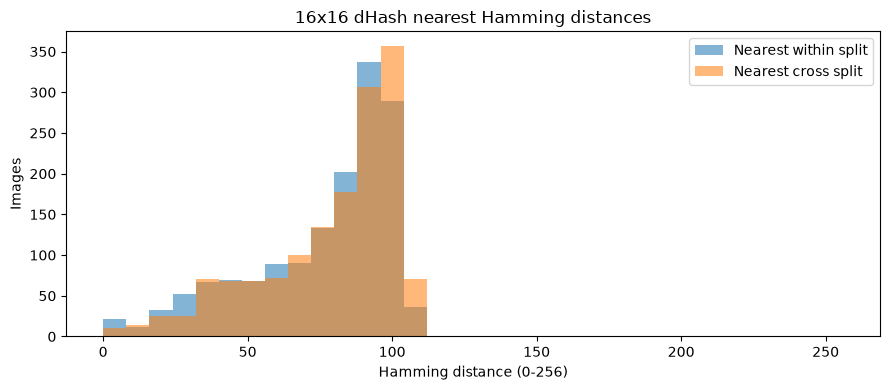

Twelve closest cross-split pairs at 16x16 resolution (ranked, not thresholded):


,left_split,left_image,right_split,right_image,hamming_distance_16x16
0,train,01_PCB__1463.jpg,valid,01_PCB__1459.jpg,1
1,train,01_PCB__1463.jpg,valid,01_PCB__1455.jpg,2
2,train,01_PCB__1479.jpg,test,01_PCB__1483.jpg,2
3,train,01_PCB__1479.jpg,test,01_PCB__1487.jpg,2
4,train,01_PCB__1399.jpg,test,01_PCB__1395.jpg,3
5,train,01_PCB__1403.jpg,test,01_PCB__1395.jpg,3
6,train,01_PCB__1188.jpg,valid,01_PCB__1156.jpg,4
7,train,01_PCB__1155.jpg,test,01_PCB__1187.jpg,9
8,train,01_PCB__855.jpg,test,01_PCB__912.jpg,10
9,train,01_PCB__864.jpg,test,01_PCB__1253.jpg,10


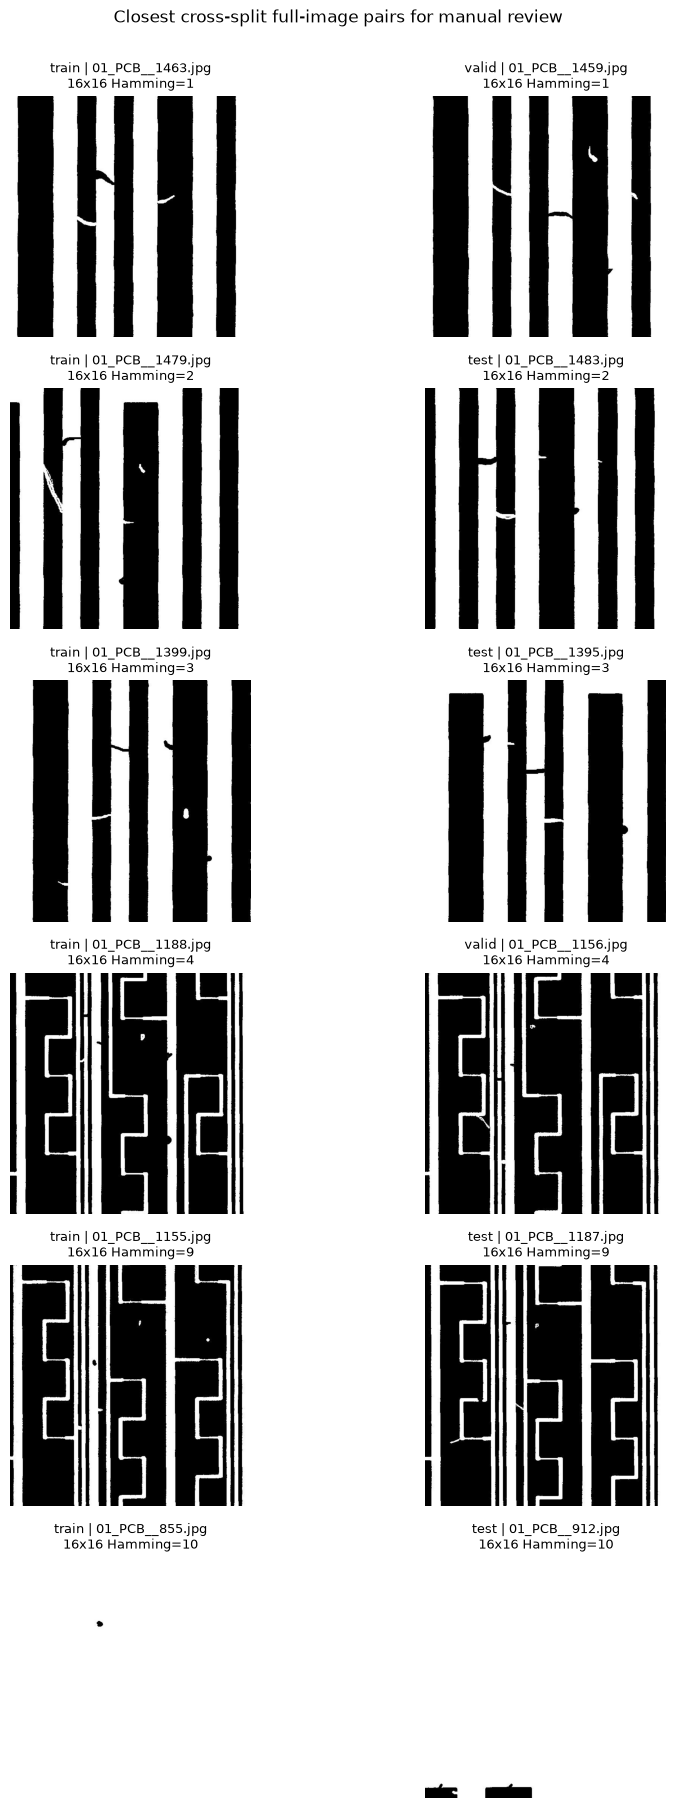

In [48]:
DHASH_MAX_DISTANCE = 4
DHASH_HIGH_RES_SIZE = 16
dhash_by_split = {split: [] for split in SPLITS}
dhash16_by_split = {split: [] for split in SPLITS}
dhash16_by_name = {}
for row in manifest.itertuples():
    with Image.open(row.image_path) as source:
        rgb_image = source.convert("RGB")
        hash_8 = int(str(imagehash.dhash(rgb_image, hash_size=8)), 16)
        hash_16 = int(str(imagehash.dhash(rgb_image, hash_size=DHASH_HIGH_RES_SIZE)), 16)
    dhash_by_split[row.split].append((row.image_name, hash_8))
    dhash16_by_split[row.split].append((row.image_name, hash_16))
    dhash16_by_name[row.image_name] = hash_16

near_duplicate_counts = []
near_duplicate_examples = []
for left_split, right_split in combinations(SPLITS, 2):
    pair_matches = []
    for left_name, left_hash in dhash_by_split[left_split]:
        for right_name, right_hash in dhash_by_split[right_split]:
            distance = (left_hash ^ right_hash).bit_count()
            if distance <= DHASH_MAX_DISTANCE:
                pair_matches.append({
                    "left_split": left_split,
                    "left_image": left_name,
                    "right_split": right_split,
                    "right_image": right_name,
                    "hamming_distance": distance,
                    "hamming_distance_16x16": (
                        dhash16_by_name[left_name] ^ dhash16_by_name[right_name]
                    ).bit_count(),
                })
    near_duplicate_counts.append({
        "split_pair": f"{left_split}/{right_split}",
        "near_duplicate_pairs_8x8_le_4": len(pair_matches),
    })
    near_duplicate_examples.extend(pair_matches)

print("Legacy dHash 8x8 (threshold 4/64), retained for comparison:")
display(pd.DataFrame(near_duplicate_counts))
print(f"Legacy candidate pairs: {len(near_duplicate_examples)}")

nearest_within = {row.image_name: np.inf for row in manifest.itertuples()}
nearest_cross = {row.image_name: np.inf for row in manifest.itertuples()}
best_cross_pairs = []
for split_name, split_items in dhash16_by_split.items():
    for (left_name, left_hash), (right_name, right_hash) in combinations(split_items, 2):
        distance = (left_hash ^ right_hash).bit_count()
        nearest_within[left_name] = min(nearest_within[left_name], distance)
        nearest_within[right_name] = min(nearest_within[right_name], distance)

for left_split, right_split in combinations(SPLITS, 2):
    for left_name, left_hash in dhash16_by_split[left_split]:
        for right_name, right_hash in dhash16_by_split[right_split]:
            distance = (left_hash ^ right_hash).bit_count()
            nearest_cross[left_name] = min(nearest_cross[left_name], distance)
            nearest_cross[right_name] = min(nearest_cross[right_name], distance)
            best_cross_pairs.append((
                distance, left_split, left_name, right_split, right_name
            ))
best_cross_pairs.sort()

nearest_distances = pd.DataFrame({
    "nearest_within_split": list(nearest_within.values()),
    "nearest_cross_split": list(nearest_cross.values()),
})
print("16x16 dHash nearest-distance distributions (256 bits); compare within vs cross split to calibrate candidates:")
display(nearest_distances.agg(["min", "median", "mean", "max"]).round(1))
figure, axis = plt.subplots(figsize=(9, 4))
histogram_bins = np.arange(0, 257, 8)
axis.hist(nearest_distances["nearest_within_split"], bins=histogram_bins, alpha=0.55, label="Nearest within split")
axis.hist(nearest_distances["nearest_cross_split"], bins=histogram_bins, alpha=0.55, label="Nearest cross split")
axis.set(title="16x16 dHash nearest Hamming distances", xlabel="Hamming distance (0-256)", ylabel="Images")
axis.legend()
figure.tight_layout()
plt.show()

candidate_rows = [
    {
        "left_split": left_split,
        "left_image": left_name,
        "right_split": right_split,
        "right_image": right_name,
        "hamming_distance_16x16": distance,
    }
    for distance, left_split, left_name, right_split, right_name in best_cross_pairs[:12]
]
print("Twelve closest cross-split pairs at 16x16 resolution (ranked, not thresholded):")
display(pd.DataFrame(candidate_rows))
selected_pairs = []
seen_images = set()
for pair in candidate_rows:
    pair_images = {pair["left_image"], pair["right_image"]}
    if pair_images & seen_images:
        continue
    selected_pairs.append(pair)
    seen_images.update(pair_images)
    if len(selected_pairs) == 6:
        break

figure, axes = plt.subplots(len(selected_pairs), 2, figsize=(10, 3 * len(selected_pairs)), squeeze=False)
for row_index, pair in enumerate(selected_pairs):
    for column_index, side in enumerate(("left", "right")):
        image_name = pair[f"{side}_image"]
        image_row = manifest.loc[manifest["image_name"] == image_name].iloc[0]
        with Image.open(image_row["image_path"]) as source:
            axes[row_index, column_index].imshow(source.convert("RGB"))
        axes[row_index, column_index].set_title(
            f"{pair[f'{side}_split']} | {image_name}\n"
            f"16x16 Hamming={pair['hamming_distance_16x16']}",
            fontsize=9,
        )
        axes[row_index, column_index].axis("off")
figure.suptitle("Closest cross-split full-image pairs for manual review", y=1.002)
figure.tight_layout()
plt.show()

Balanced 16x16 dHash calibration: each image compared with 100 random candidates within and across splits.
Overall sampled-nearest distance summary:


,nearest_within_100,nearest_cross_100
min,0.0,1.0
median,92.0,93.0
mean,85.7,85.5
max,115.0,116.0


Per-split sampled-nearest distance summary:


nearest_within_100                     nearest_cross_100                 \
                  median       mean min  max            median       mean min   
split                                                                           
train               92.0  85.578333   0  115              92.0  85.092500   1   
valid               97.0  89.966667   1  111              96.0  89.986667  29   
test                90.5  82.160000   0  114              92.5  84.506667  19   

            
       max  
split       
train  116  
valid  114  
test   113

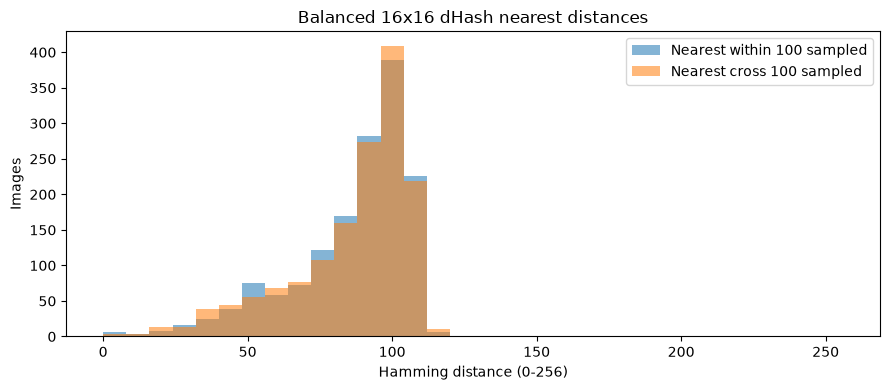

In [49]:
BALANCED_CANDIDATE_COUNT = 100
balanced_rng = np.random.default_rng(RANDOM_SEED)
balanced_nearest_rows = []
for row in manifest.itertuples():
    within_candidates = [
        (image_name, image_hash)
        for image_name, image_hash in dhash16_by_split[row.split]
        if image_name != row.image_name
    ]
    cross_candidates = [
        candidate
        for other_split in SPLITS
        if other_split != row.split
        for candidate in dhash16_by_split[other_split]
    ]
    candidate_count = min(
        BALANCED_CANDIDATE_COUNT, len(within_candidates), len(cross_candidates)
    )
    within_sample = balanced_rng.choice(len(within_candidates), size=candidate_count, replace=False)
    cross_sample = balanced_rng.choice(len(cross_candidates), size=candidate_count, replace=False)
    current_hash = dhash16_by_name[row.image_name]
    balanced_nearest_rows.append({
        "split": row.split,
        "nearest_within_100": min(
            (current_hash ^ within_candidates[index][1]).bit_count()
            for index in within_sample
        ),
        "nearest_cross_100": min(
            (current_hash ^ cross_candidates[index][1]).bit_count()
            for index in cross_sample
        ),
        "candidate_count": candidate_count,
    })
balanced_nearest = pd.DataFrame(balanced_nearest_rows)
print("Balanced 16x16 dHash calibration: each image compared with 100 random candidates within and across splits.")
print("Overall sampled-nearest distance summary:")
display(balanced_nearest[["nearest_within_100", "nearest_cross_100"]].agg(
    ["min", "median", "mean", "max"]
).round(1))
print("Per-split sampled-nearest distance summary:")
display(balanced_nearest.groupby("split")[
    ["nearest_within_100", "nearest_cross_100"]
].agg(["median", "mean", "min", "max"]).reindex(SPLITS))
figure, axis = plt.subplots(figsize=(9, 4))
axis.hist(balanced_nearest["nearest_within_100"], bins=np.arange(0, 257, 8), alpha=0.55, label="Nearest within 100 sampled")
axis.hist(balanced_nearest["nearest_cross_100"], bins=np.arange(0, 257, 8), alpha=0.55, label="Nearest cross 100 sampled")
axis.set(title="Balanced 16x16 dHash nearest distances", xlabel="Hamming distance (0-256)", ylabel="Images")
axis.legend()
figure.tight_layout()
plt.show()

Khoảng cách hash chỉ dùng để xếp hạng ứng viên; cần kiểm tra ảnh và xác minh board/source ID trước khi quyết định split lại.

In [56]:
FILENAME_ID_PATTERN = r"__(\d+)(?:\.[^.]+)?$"
group_manifest = manifest.assign(
    filename_id=pd.to_numeric(
        manifest["image_name"].str.extract(FILENAME_ID_PATTERN, expand=False),
        errors="coerce",
    ).astype("Int64")
)
recognized_images = int(group_manifest["filename_id"].notna().sum())
print(f"Numeric suffix IDs parsed: {recognized_images}/{len(group_manifest)}")

numeric_id_manifest = group_manifest.dropna(subset=["filename_id"]).copy()
if numeric_id_manifest.empty:
    print("No numeric filename suffixes found with the expected '__<digits>' rule.")
else:
    split_id_summary = numeric_id_manifest.groupby("split").agg(
        images=("image_name", "size"),
        min_id=("filename_id", "min"),
        max_id=("filename_id", "max"),
        unique_ids=("filename_id", "nunique"),
    ).reindex(SPLITS)
    display(split_id_summary)

    duplicate_ids = numeric_id_manifest.loc[
        numeric_id_manifest["filename_id"].duplicated(keep=False)
    ].sort_values(["filename_id", "split"])
    print(f"Images sharing a numeric suffix ID: {len(duplicate_ids)}")
    if not duplicate_ids.empty:
        display(duplicate_ids[["split", "image_name", "filename_id"]])

    ordered_ids = numeric_id_manifest.sort_values("filename_id").reset_index(drop=True)
    cross_split_neighbors = []
    for left_index, left_row in enumerate(ordered_ids.itertuples(index=False)):
        for right_row in ordered_ids.iloc[left_index + 1 :].itertuples(index=False):
            id_gap = int(right_row.filename_id - left_row.filename_id)
            if id_gap > 5:
                break
            if left_row.split != right_row.split:
                cross_split_neighbors.append({
                    "left_split": left_row.split,
                    "left_image": left_row.image_name,
                    "right_split": right_row.split,
                    "right_image": right_row.image_name,
                    "id_gap": id_gap,
                })

    cross_split_neighbors = pd.DataFrame(cross_split_neighbors)
    print(
        "Cross-split image pairs with numeric ID gap <= 5: "
        f"{len(cross_split_neighbors)}"
    )
    if not cross_split_neighbors.empty:
        print("Cross-split neighbor pair counts by numeric gap:")
        display(cross_split_neighbors["id_gap"].value_counts().sort_index().rename("pairs").to_frame())
        print("Closest cross-split numeric-ID neighbors (first 30):")
        display(cross_split_neighbors.sort_values(
            ["id_gap", "left_image", "right_image"]
        ).head(30))

if near_duplicate_examples:
    dhash_id_pairs = pd.DataFrame(near_duplicate_examples)
    for side in ("left", "right"):
        dhash_id_pairs[f"{side}_filename_id"] = pd.to_numeric(
            dhash_id_pairs[f"{side}_image"].str.extract(
                FILENAME_ID_PATTERN, expand=False
            ),
            errors="coerce",
        ).astype("Int64")
    dhash_id_pairs["filename_id_gap"] = (
        dhash_id_pairs["left_filename_id"] - dhash_id_pairs["right_filename_id"]
    ).abs()
    print("dHash pair matches grouped by numeric filename-ID gap:")
    display(dhash_id_pairs["filename_id_gap"].value_counts().sort_index().rename("pairs").to_frame())
    print("All dHash matches with numeric filename IDs and gaps:")
    display(dhash_id_pairs.sort_values(
        ["filename_id_gap", "hamming_distance"]
    ))

Numeric suffix IDs parsed: 1500/1500


,images,min_id,max_id,unique_ids
split,,,,
train,1200,1,1500,1200
valid,150,8,1488,150
test,150,13,1496,150


Images sharing a numeric suffix ID: 0
Cross-split image pairs with numeric ID gap <= 5: 2559
Cross-split neighbor pair counts by numeric gap:


,pairs
id_gap,
1,512
2,501
3,516
4,510
5,520


Closest cross-split numeric-ID neighbors (first 30):


,left_split,left_image,right_split,right_image,id_gap
16,valid,01_PCB__10.jpg,train,01_PCB__11.jpg,1
163,train,01_PCB__100.jpg,test,01_PCB__101.jpg,1
1698,train,01_PCB__1000.jpg,valid,01_PCB__1001.jpg,1
1700,valid,01_PCB__1001.jpg,train,01_PCB__1002.jpg,1
1704,train,01_PCB__1002.jpg,valid,01_PCB__1003.jpg,1
1705,valid,01_PCB__1003.jpg,train,01_PCB__1004.jpg,1
1714,train,01_PCB__1009.jpg,valid,01_PCB__1010.jpg,1
164,test,01_PCB__101.jpg,train,01_PCB__102.jpg,1
1715,valid,01_PCB__1010.jpg,train,01_PCB__1011.jpg,1
1724,train,01_PCB__1018.jpg,test,01_PCB__1019.jpg,1


dHash pair matches grouped by numeric filename-ID gap:


,pairs
filename_id_gap,
1,5
2,1
3,1
4,4
5,1
8,2
31,1
32,3
33,1


All dHash matches with numeric filename IDs and gaps:


,left_split,left_image,right_split,right_image,hamming_distance,hamming_distance_16x16,left_filename_id,right_filename_id,filename_id_gap
10,train,01_PCB__647.jpg,valid,01_PCB__648.jpg,1,14,647,648,1
25,train,01_PCB__858.jpg,test,01_PCB__857.jpg,1,18,858,857,1
2,train,01_PCB__1171.jpg,valid,01_PCB__1172.jpg,3,42,1171,1172,1
15,train,01_PCB__1186.jpg,test,01_PCB__1187.jpg,4,32,1186,1187,1
24,train,01_PCB__856.jpg,test,01_PCB__857.jpg,4,19,856,857,1
11,train,01_PCB__650.jpg,valid,01_PCB__648.jpg,2,37,650,648,2
12,train,01_PCB__651.jpg,valid,01_PCB__648.jpg,3,29,651,648,3
5,train,01_PCB__1463.jpg,valid,01_PCB__1459.jpg,1,1,1463,1459,4
17,train,01_PCB__1399.jpg,test,01_PCB__1395.jpg,1,3,1399,1395,4
9,train,01_PCB__644.jpg,valid,01_PCB__648.jpg,2,46,644,648,4


In [57]:
dhash16_top_pairs = pd.DataFrame([
    {
        "hamming_distance_16x16": distance,
        "left_split": left_split,
        "left_image": left_name,
        "right_split": right_split,
        "right_image": right_name,
    }
    for distance, left_split, left_name, right_split, right_name in best_cross_pairs[:20]
])
for side in ("left", "right"):
    dhash16_top_pairs[f"{side}_filename_id"] = pd.to_numeric(
        dhash16_top_pairs[f"{side}_image"].str.extract(FILENAME_ID_PATTERN, expand=False),
        errors="coerce",
    ).astype("Int64")
dhash16_top_pairs["filename_id_gap"] = (
    dhash16_top_pairs["left_filename_id"] - dhash16_top_pairs["right_filename_id"]
).abs()
print("Numeric-ID gaps for the 20 closest cross-split 16x16 dHash pairs:")
display(dhash16_top_pairs)

Numeric-ID gaps for the 20 closest cross-split 16x16 dHash pairs:


,hamming_distance_16x16,left_split,left_image,right_split,right_image,left_filename_id,right_filename_id,filename_id_gap
0,1,train,01_PCB__1463.jpg,valid,01_PCB__1459.jpg,1463,1459,4
1,2,train,01_PCB__1463.jpg,valid,01_PCB__1455.jpg,1463,1455,8
2,2,train,01_PCB__1479.jpg,test,01_PCB__1483.jpg,1479,1483,4
3,2,train,01_PCB__1479.jpg,test,01_PCB__1487.jpg,1479,1487,8
4,3,train,01_PCB__1399.jpg,test,01_PCB__1395.jpg,1399,1395,4
5,3,train,01_PCB__1403.jpg,test,01_PCB__1395.jpg,1403,1395,8
6,4,train,01_PCB__1188.jpg,valid,01_PCB__1156.jpg,1188,1156,32
7,9,train,01_PCB__1155.jpg,test,01_PCB__1187.jpg,1155,1187,32
8,10,train,01_PCB__855.jpg,test,01_PCB__912.jpg,855,912,57
9,10,train,01_PCB__864.jpg,test,01_PCB__1253.jpg,864,1253,389


## 9. Phân tích hậu tố số và nguy cơ split theo board

Prefix trước `__` luôn là `01_PCB`, nên không phân nhóm được. Cell kế tiếp parse số sau `__`, tóm tắt dải ID theo split, đếm cặp ID cách nhau tối đa 5 nhưng thuộc khác split, và đối chiếu gap ID của các cặp dHash. ID gần nhau cùng dHash gần là ứng viên cần kiểm tra ảnh gốc; riêng ID liền kề không chứng minh cùng board. Cho đến khi xác minh quy ước đặt tên hoặc có `board_id`, không thể kết luận split độc lập theo board hay khẳng định leakage.

## Kết luận và handoff Stage 2

**Đây là bài toán object detection đa lớp**: 1.500 ảnh 640×640 có 10.013 box, trung vị 7 box/ảnh. Các số liệu dưới đây mô tả bộ file hiện có; chưa có metadata để xác minh nguồn split, template hay board ID.

### Hình học box và kiến trúc

- Median box là 35×33 px; 32,0% box có diện tích `<32² px`. Tỷ lệ nhỏ theo lớp: `mousebite` 49,7%, `spur` 42,1%, `pin-hole` 43,5%, nhưng `short` 9,9%. Median aspect ratio `short` là 1,188 (width/height), không ủng hộ giả thuyết box `short` thường cao và hẹp ở median; dải p10–p90 vẫn rộng.
- So sánh 30.868 cặp box trong cùng ảnh không thấy IoU ≥0,5 hoặc trùng tọa độ. Đây chỉ là kiểm tra overlap hình học, không xác nhận chất lượng từng box.
- Có heatmap tâm box theo lớp và 9 anchor Euclidean K-means fit trên train. Anchor là gợi ý khởi tạo, không thay thế đánh giá anchor theo IoU/recall của detector.
- Median box sau resize còn 22,8×21,5 px ở 416 và 17,5×16,5 px ở 320. Ở stride 8 tương ứng khoảng 2,84×2,68 và 2,19×2,06 ô; stride 16/32 giữ ít hơn. Simple CNN nên có head ở stride nhỏ (ví dụ 8) và cần đo recall. Stride không phải receptive field; receptive field chính xác chỉ xác định được sau khi chọn kiến trúc.

### Pixel, split và nguồn dữ liệu

- Pixel moments RGB pooled theo split (RGB/255): train mean `(0,652, 0,652, 0,652)`, std `(0,475, 0,475, 0,475)`; valid mean khoảng `0,637`, std `0,478`; test mean `0,652`, std `0,475`. Dùng mean/std tính từ train làm normalization candidate, rồi so sánh với preprocessing của pretrained backbone trên validation.
- Valid/test mỗi split có 150 ảnh. Notebook báo 95% Wilson CI cho prevalence từng lớp và image-bootstrap CI cho mean boxes/image; ví dụ valid 6,70 (CI 6,41–6,99), test 6,56 (CI 6,28–6,86). CI hiện tại ở cấp ảnh và chưa xử lý tương quan board. Chưa có prediction nên chưa thể tính CI cho AP; khi đánh giá detector, bootstrap AP theo board nếu có ID đáng tin cậy.
- Các thư mục hiện có là `train=1200`, `valid=150`, `test=150`; không tìm thấy split manifest/provenance. Vì vậy chưa thể nói đây là split gốc DeepPCB hay tự chia. Cần ghi rõ nguồn và quy trình split trước khi so sánh với benchmark khác.
- Không tìm thấy template/reference assets trong data root; notebook hiện không sử dụng template. Nếu bản DeepPCB này có template ở nguồn khác, cần bổ sung đường dẫn và ánh xạ template-board trước khi phân tích registration/subtraction.

### Nhãn, kiểm tra trực quan và similarity

- 72,3% ảnh chứa ít nhất 5/6 lớp; prevalence này mô tả độ phủ nhãn image-level, không phải metric phân loại. Pairwise co-occurrence lift 0,97–1,05; phân bố phù hợp với khả năng defect được tạo có kiểm soát/chèn nhân tạo, nhưng chưa chứng minh provenance.
- Không có ảnh board sạch/âm tính, nên chưa đo được false positive trên board không lỗi. Cần bổ sung clean-board set có xác minh.
- Overlay mẫu gồm 3 ảnh mỗi split; crop gallery gồm mỗi lớp × mỗi split. Đây là spot-check, không phải audit thủ công toàn bộ 10.013 box.
- dHash 16×16 với 100 ứng viên lấy mẫu cho mỗi ảnh có median nearest 92 bit trong split và 93 bit cross-split; histogram chồng lấn mạnh. Notebook xếp hạng và hiển thị các cặp gần nhất cạnh nhau; hash đơn lẻ không đủ để kết luận duplicate/leakage. Hậu tố ID đan xen giữa split nên cần xác minh `board_id` trước khi tái chia dữ liệu.

### Handoff

Giữ ảnh gốc và box `xyxy` làm nguồn chuẩn; augment chỉ trên train và biến đổi box cùng ảnh. So sánh detector ở cùng input/evaluator, ưu tiên head stride nhỏ cho defect nhỏ. Chọn checkpoint/threshold trên validation; chỉ mở test cho đánh giá cuối. Báo cáo mAP@0.5, mAP@0.5:0.95, AP từng lớp, precision/recall và CI bootstrap phù hợp với đơn vị board. Trước khi kết luận hiệu năng, xác minh split provenance, tìm/bổ sung template nếu có, và bổ sung ảnh clean-board.

In [58]:
stage2_targets = annotations[[
    "split", "image_name", "class_id", "class_index", "class_name",
    "x1", "y1", "x2", "y2", "image_width", "image_height",
]].copy()
stage2_targets["x_center_norm"] = (
    (stage2_targets["x1"] + stage2_targets["x2"])
    / (2 * stage2_targets["image_width"])
)
stage2_targets["y_center_norm"] = (
    (stage2_targets["y1"] + stage2_targets["y2"])
    / (2 * stage2_targets["image_height"])
)
stage2_targets["width_norm"] = (
    (stage2_targets["x2"] - stage2_targets["x1"])
    / stage2_targets["image_width"]
)
stage2_targets["height_norm"] = (
    (stage2_targets["y2"] - stage2_targets["y1"])
    / stage2_targets["image_height"]
)
normalized_box_columns = [
    "x_center_norm", "y_center_norm", "width_norm", "height_norm"
]
if not np.isfinite(stage2_targets[normalized_box_columns].to_numpy()).all():
    raise ValueError("Normalized box targets contain non-finite values")
if not stage2_targets[normalized_box_columns].ge(0).all().all() or not stage2_targets[normalized_box_columns].le(1).all().all():
    raise ValueError("Normalized box targets fall outside [0, 1]")

stage2_targets = stage2_targets.sort_values(
    ["split", "image_name", "class_index", "y1", "x1"]
).reset_index(drop=True)
OUTPUT_ROOT = Path(os.environ.get(
    "PCB_OUTPUT_ROOT", deep_pcb_base.parent / "derived"
)).expanduser()
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

targets_csv_path = OUTPUT_ROOT / "stage2_targets.csv"
stage2_targets.to_csv(targets_csv_path, index=False)
class_mapping_path = OUTPUT_ROOT / "class_mapping.csv"
pd.DataFrame({
    "class_id": [CLASS_ID_BASE + index for index in range(len(CLASS_NAMES))],
    "class_index": list(range(len(CLASS_NAMES))),
    "class_name": CLASS_NAMES,
}).to_csv(class_mapping_path, index=False)

yolo_root = OUTPUT_ROOT / "yolo_labels"
targets_by_image = {
    key: rows for key, rows in stage2_targets.groupby(["split", "image_name"])
}
yolo_file_count = 0
for image_row in manifest.itertuples():
    image_targets = targets_by_image.get((image_row.split, image_row.image_name))
    label_lines = []
    if image_targets is not None:
        label_lines = [
            f"{int(target.class_index)} {target.x_center_norm:.6f} "
            f"{target.y_center_norm:.6f} {target.width_norm:.6f} "
            f"{target.height_norm:.6f}"
            for target in image_targets.itertuples(index=False)
        ]
    label_output_path = yolo_root / image_row.split / f"{Path(image_row.image_name).stem}.txt"
    label_output_path.parent.mkdir(parents=True, exist_ok=True)
    label_output_path.write_text(
        "\n".join(label_lines) + ("\n" if label_lines else ""),
        encoding="utf-8",
    )
    yolo_file_count += 1

candidate_frames = []
if near_duplicate_examples:
    legacy_candidates = pd.DataFrame(near_duplicate_examples).rename(
        columns={"hamming_distance": "hamming_distance_8x8"}
    )
    legacy_candidates["candidate_method"] = "dHash_8x8_hamming_le_4"
    candidate_frames.append(legacy_candidates)
if not dhash16_top_pairs.empty:
    high_resolution_candidates = dhash16_top_pairs.copy()
    high_resolution_candidates["candidate_method"] = "top_ranked_dHash_16x16"
    candidate_frames.append(high_resolution_candidates)

if candidate_frames:
    candidate_review = pd.concat(candidate_frames, ignore_index=True, sort=False)
else:
    candidate_review = pd.DataFrame(columns=[
        "candidate_method", "left_split", "left_image", "right_split", "right_image"
    ])
for side in ("left", "right"):
    id_column = f"{side}_filename_id"
    if id_column not in candidate_review:
        candidate_review[id_column] = pd.NA
    parsed_ids = pd.to_numeric(
        candidate_review[f"{side}_image"].astype("string").str.extract(
            FILENAME_ID_PATTERN, expand=False
        ),
        errors="coerce",
    ).astype("Int64")
    candidate_review[id_column] = candidate_review[id_column].fillna(parsed_ids)
candidate_review["filename_id_gap"] = (
    candidate_review["left_filename_id"] - candidate_review["right_filename_id"]
).abs()
candidate_review_path = OUTPUT_ROOT / "near_duplicate_review_candidates.csv"
candidate_review.to_csv(candidate_review_path, index=False)

print(f"Stage 2 target rows: {len(stage2_targets):,} | columns: {len(stage2_targets.columns)}")
print("Normalized box target range:")
display(stage2_targets[normalized_box_columns].agg(["min", "max"]).round(4))
print("Pixel and normalized targets (sample):")
display(stage2_targets.head(8))
print(f"YOLO label files written: {yolo_file_count:,}/{len(manifest):,}")
print(f"Candidate pairs written: {len(candidate_review):,} (review candidates, not confirmed duplicates)")
print("Exported artifacts:")
for artifact_path in (targets_csv_path, class_mapping_path, yolo_root, candidate_review_path):
    print(f"- {display_path(artifact_path)}")

Stage 2 target rows: 10,013 | columns: 15
Normalized box target range:


,x_center_norm,y_center_norm,width_norm,height_norm
min,0.0195,0.0148,0.0281,0.0297
max,0.9844,0.9781,0.2703,0.2375


Pixel and normalized targets (sample):


,split,image_name,class_id,class_index,class_name,x1,y1,x2,y2,image_width,image_height,x_center_norm,y_center_norm,width_norm,height_norm
0,test,01_PCB__101.jpg,1,0,open,330,244,362,277,640,640,0.540625,0.407031,0.050000,0.051562
1,test,01_PCB__101.jpg,2,1,short,327,55,361,104,640,640,0.537500,0.124219,0.053125,0.076563
2,test,01_PCB__101.jpg,3,2,mousebite,68,60,100,87,640,640,0.131250,0.114844,0.050000,0.042188
3,test,01_PCB__101.jpg,3,2,mousebite,180,109,215,140,640,640,0.308594,0.194531,0.054688,0.048438
4,test,01_PCB__101.jpg,3,2,mousebite,176,172,214,202,640,640,0.304688,0.292187,0.059375,0.046875
5,test,01_PCB__101.jpg,3,2,mousebite,272,538,313,569,640,640,0.457031,0.864844,0.064062,0.048438
6,test,01_PCB__101.jpg,5,4,copper,190,388,221,429,640,640,0.321094,0.638281,0.048438,0.064062
7,test,01_PCB__101.jpg,6,5,pin-hole,228,187,271,213,640,640,0.389844,0.312500,0.067187,0.040625


YOLO label files written: 1,500/1,500
Candidate pairs written: 47 (review candidates, not confirmed duplicates)
Exported artifacts:
- Data/derived/stage2_targets.csv
- Data/derived/class_mapping.csv
- Data/derived/yolo_labels
- Data/derived/near_duplicate_review_candidates.csv


In [59]:
roundtrip_targets = pd.read_csv(targets_csv_path)
roundtrip_class_mapping = pd.read_csv(class_mapping_path)
roundtrip_candidates = pd.read_csv(candidate_review_path)
written_yolo_paths = sorted(yolo_root.rglob("*.txt"))
yolo_line_count = 0
for label_path in written_yolo_paths:
    for line in label_path.read_text(encoding="utf-8").splitlines():
        fields = line.split()
        if len(fields) != 5:
            raise ValueError(f"Invalid YOLO row in {display_path(label_path)}")
        class_index = int(fields[0])
        normalized_values = np.asarray(fields[1:], dtype=float)
        if not 0 <= class_index < len(CLASS_NAMES):
            raise ValueError(f"Invalid class index in {display_path(label_path)}")
        if not np.isfinite(normalized_values).all() or np.any(
            (normalized_values < 0) | (normalized_values > 1)
        ):
            raise ValueError(f"Invalid normalized target in {display_path(label_path)}")
        yolo_line_count += 1

if len(roundtrip_targets) != len(stage2_targets):
    raise ValueError("CSV round-trip changed the number of Stage 2 target rows")
if len(roundtrip_class_mapping) != len(CLASS_NAMES):
    raise ValueError("Class mapping export does not cover every class")
if len(written_yolo_paths) != len(manifest) or yolo_line_count != len(stage2_targets):
    raise ValueError("YOLO export file or annotation counts do not match the source manifest")
if len(roundtrip_candidates) != len(candidate_review):
    raise ValueError("Candidate review CSV round-trip changed the row count")
print(
    f"Export validation passed: {len(roundtrip_targets):,} CSV targets, "
    f"{len(roundtrip_class_mapping):,} class mappings, "
    f"{len(written_yolo_paths):,} YOLO files / {yolo_line_count:,} rows, "
    f"{len(roundtrip_candidates):,} review candidates."
)

Export validation passed: 10,013 CSV targets, 6 class mappings, 1,500 YOLO files / 10,013 rows, 47 review candidates.
